In [ ]:
import pandas as pd
import io

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Borutta_DBSCAN.csv to Borutta_DBSCAN.csv


In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
!pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.3 MB/s eta 0:00:00


In [ ]:
######Importing data
data= pd.read_csv(r"C:\Users\edmun\Desktop\Nana Kee Summer\Data\default of credit card clients.csv")
data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default Payment
0,23333,Female,University,Married,24,2,2,-1,-1,-2,...,3,3,3,3,689,3,3,3,3,Yes
1,123333,Female,University,Single,26,-1,2,3,3,3,...,3272,3455,3261,3,1333,1333,1333,3,2333,Yes
2,93333,Female,University,Single,34,3,3,3,3,3,...,14331,14948,15549,1518,1533,1333,1333,1333,5333,No
3,53333,Female,University,Married,37,3,3,3,3,3,...,28314,28959,29547,2333,2319,1233,1133,1369,1333,No
4,53333,Male,University,Married,57,-1,3,-1,3,3,...,23943,19146,19131,2333,36681,13333,9333,689,679,No


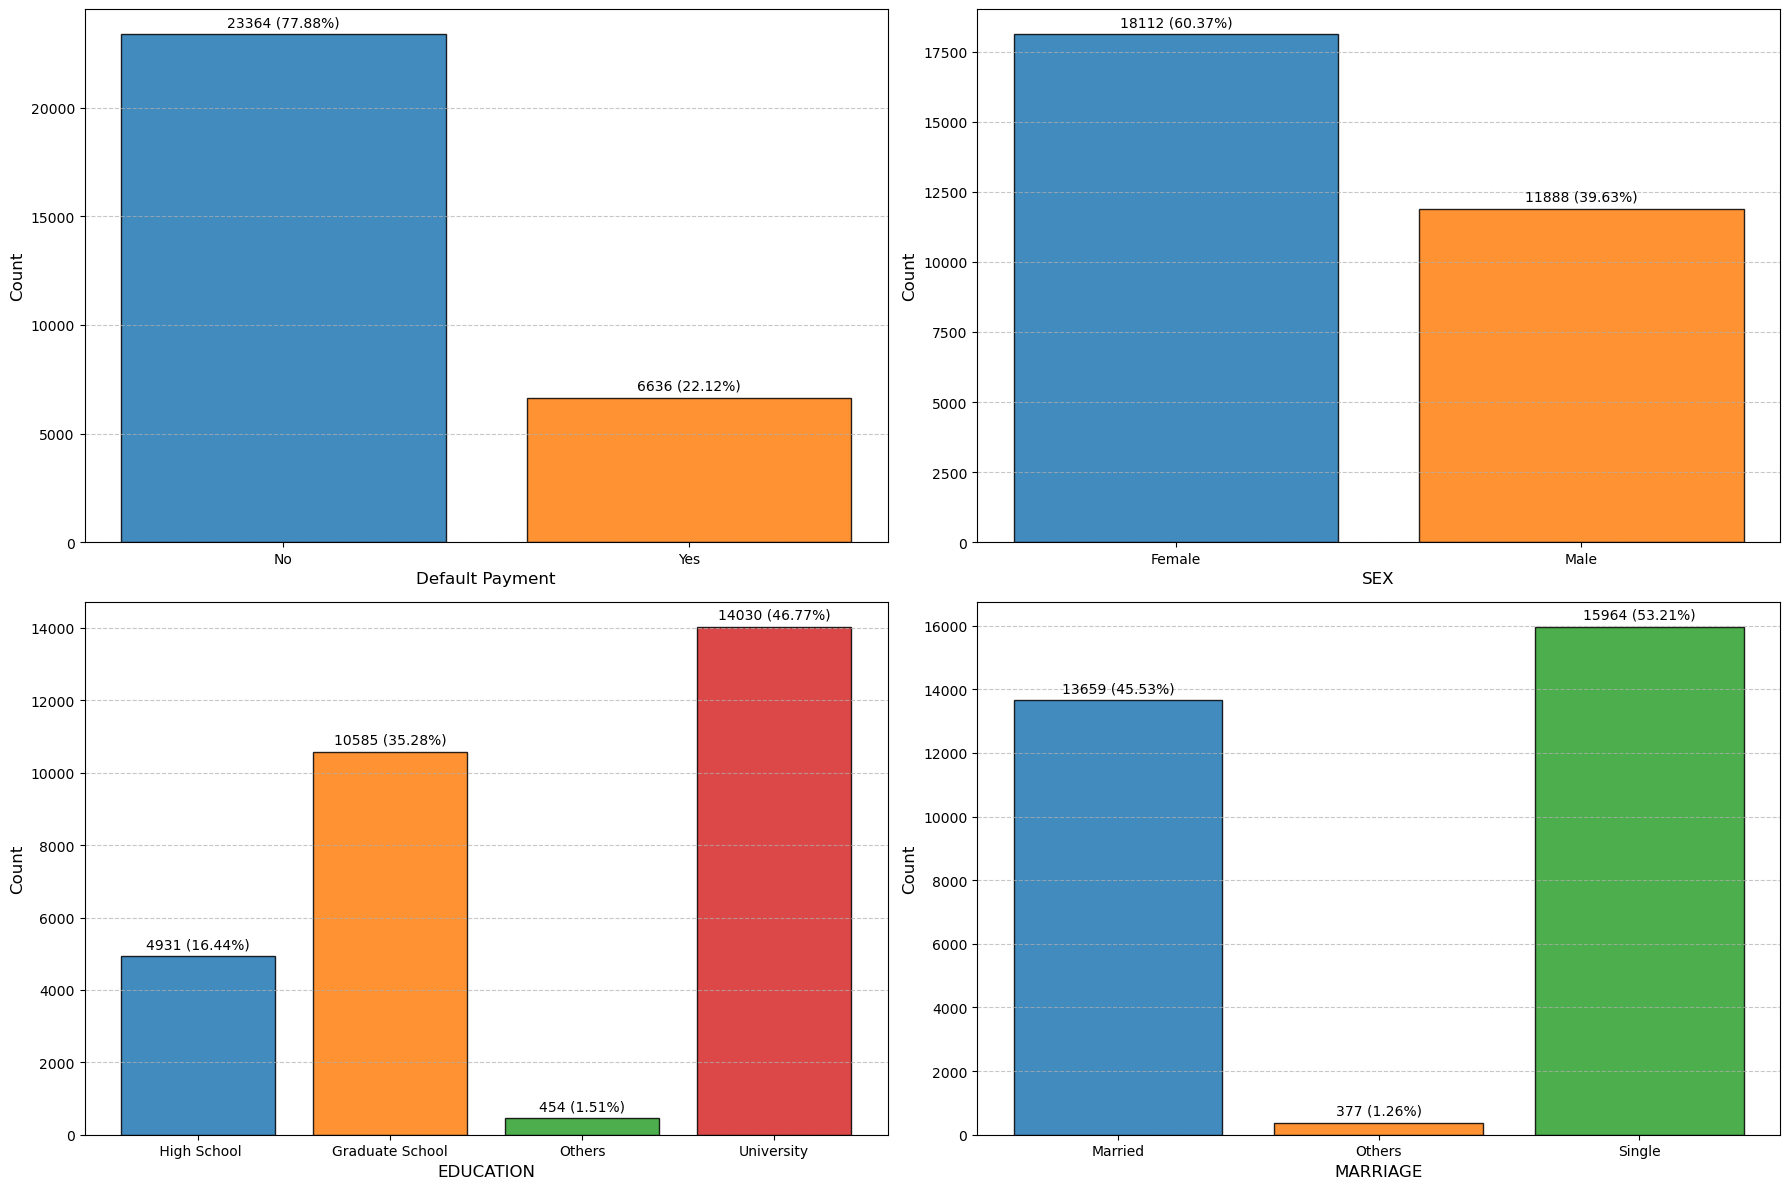

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the features as they appear exactly in the dataset
features = ['Default Payment', 'SEX', 'EDUCATION', 'MARRIAGE']

# Create a figure with 2 rows and 2 columns for bar charts
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Generate bar charts for each feature
for ax, feature in zip(axes, features):
    counts = data[feature].value_counts().sort_index()
    percentages = data[feature].value_counts(normalize=True).sort_index() * 100

    # Choose a colormap and get a color for each bar
    cmap = plt.get_cmap('tab10')  # 'tab10', 'Set2', 'Accent', etc. all work well
    colors = [cmap(i) for i in range(len(counts))]

    bars = ax.bar(counts.index.astype(str), counts, color=colors, alpha=0.85, edgecolor='black')

    # Annotate bars with count and percentage
    for bar, count, pct in zip(bars, counts, percentages):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts)*0.01,
            f'{int(count)} ({pct:.2f}%)',
            ha='center', va='bottom', fontsize=10
        )

    #ax.set_title(feature, fontsize=14)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# Boruta Algorithm

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# Step 1: Load the data
df = pd.read_csv(r"C:\Users\edmun\Desktop\Nana Kee Summer\Data\default of credit card clients.csv")

# Step 2: Prepare the features and target
target_col = 'Default Payment'
X = df.drop(columns=[target_col])
y = df[target_col]

# Step 3: Encode categorical features
# This will automatically convert all categorical/text columns into numeric columns
X_encoded = pd.get_dummies(X, drop_first=True)

# Step 4: Set up the Boruta feature selector
rf = RandomForestClassifier(
    n_jobs=-1,
    class_weight='balanced',
    max_depth=5,
    random_state=42
)
boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

# Step 5: Fit Boruta
boruta_selector.fit(X_encoded.values, y.values)

# Step 6: Print results
selected_features = X_encoded.columns[boruta_selector.support_].to_list()
print("Selected Features by Boruta:")
for feat in selected_features:
    print(feat)

# Optional: Get a DataFrame with only the selected features
X_selected = X_encoded[selected_features]

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	26
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	26
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	26
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	26
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	26
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	26
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	26
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	20
Tentative: 	2
Rejected: 	4
Iteration: 	9 / 100
Confirmed: 	20
Tentative: 	2
Rejected: 	4
Iteration: 	10 / 100
Confirmed: 	20
Tentative: 	2
Rejected: 	4
Iteration: 	11 / 100
Confirmed: 	20
Tentative: 	2
Rejected: 	4
Iteration: 	12 / 100
Confirmed: 	20
Tentative: 	2
Rejected: 	4
Iteration: 	13 / 100
Confirmed: 	20
Tentative: 	2
Rejected: 	4
Iteration: 	14 / 100
Confirmed: 	20
Tentative: 	2
Rejected: 	4
Iteration: 	15 / 100
Confirmed: 	20
Tentative: 	2
Rejected: 	4
Iteration: 	16 / 100
Confirmed: 	20
Tentative: 	2
Rejected: 	4
I

## DBSCAN for Outlier Detection

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Load the data
df = pd.read_csv(r"C:\Users\edmun\Desktop\Nana Kee Summer\Data\default of credit card clients.csv")

# Identify numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

# Apply DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X_scaled)

# Attach labels and filter out outliers (label == -1)
df['dbscan_label'] = labels
num_outliers = (labels == -1).sum()
df_db_clean = df[df['dbscan_label'] != -1].drop(columns=['dbscan_label']).reset_index(drop=True)

# Display results
print(f"DBSCAN detected and removed {num_outliers} outliers.")
print("Shape before DBSCAN:", df.shape)
print("Shape after DBSCAN:", df_db_clean.shape)

DBSCAN detected and removed 16480 outliers.
Shape before DBSCAN: (30000, 25)
Shape after DBSCAN: (13520, 24)


In [ ]:
df_db_clean

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default Payment
0,93333,Female,University,Single,34,3,3,3,3,3,...,14331,14948,15549,1518,1533,1333,1333,1333,5333,No
1,53333,Female,University,Married,37,3,3,3,3,3,...,28314,28959,29547,2333,2319,1233,1133,1369,1333,No
2,53333,Male,Graduate School,Single,37,3,3,3,3,3,...,19394,19619,23324,2533,1815,657,1333,1333,833,No
3,143333,Female,High School,Married,28,3,3,2,3,3,...,12211,11793,3719,3329,3,432,1333,1333,1333,No
4,253333,Male,Graduate School,Single,29,3,3,3,3,3,...,59696,56875,55512,3333,3333,3333,3333,3333,3333,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13515,143333,Male,University,Married,41,3,3,3,3,3,...,138262,49675,46121,6333,7333,4228,1535,2333,2333,No
13516,13333,Male,High School,Married,43,3,3,3,-2,-2,...,3,3,3,2333,3,3,3,3,3,No
13517,83333,Male,University,Single,34,2,2,2,2,2,...,77519,82637,81158,7333,3533,3,7333,3,4333,Yes
13518,153333,Male,High School,Single,43,-1,-1,-1,-1,3,...,8979,5193,3,1837,3526,8998,129,3,3,No


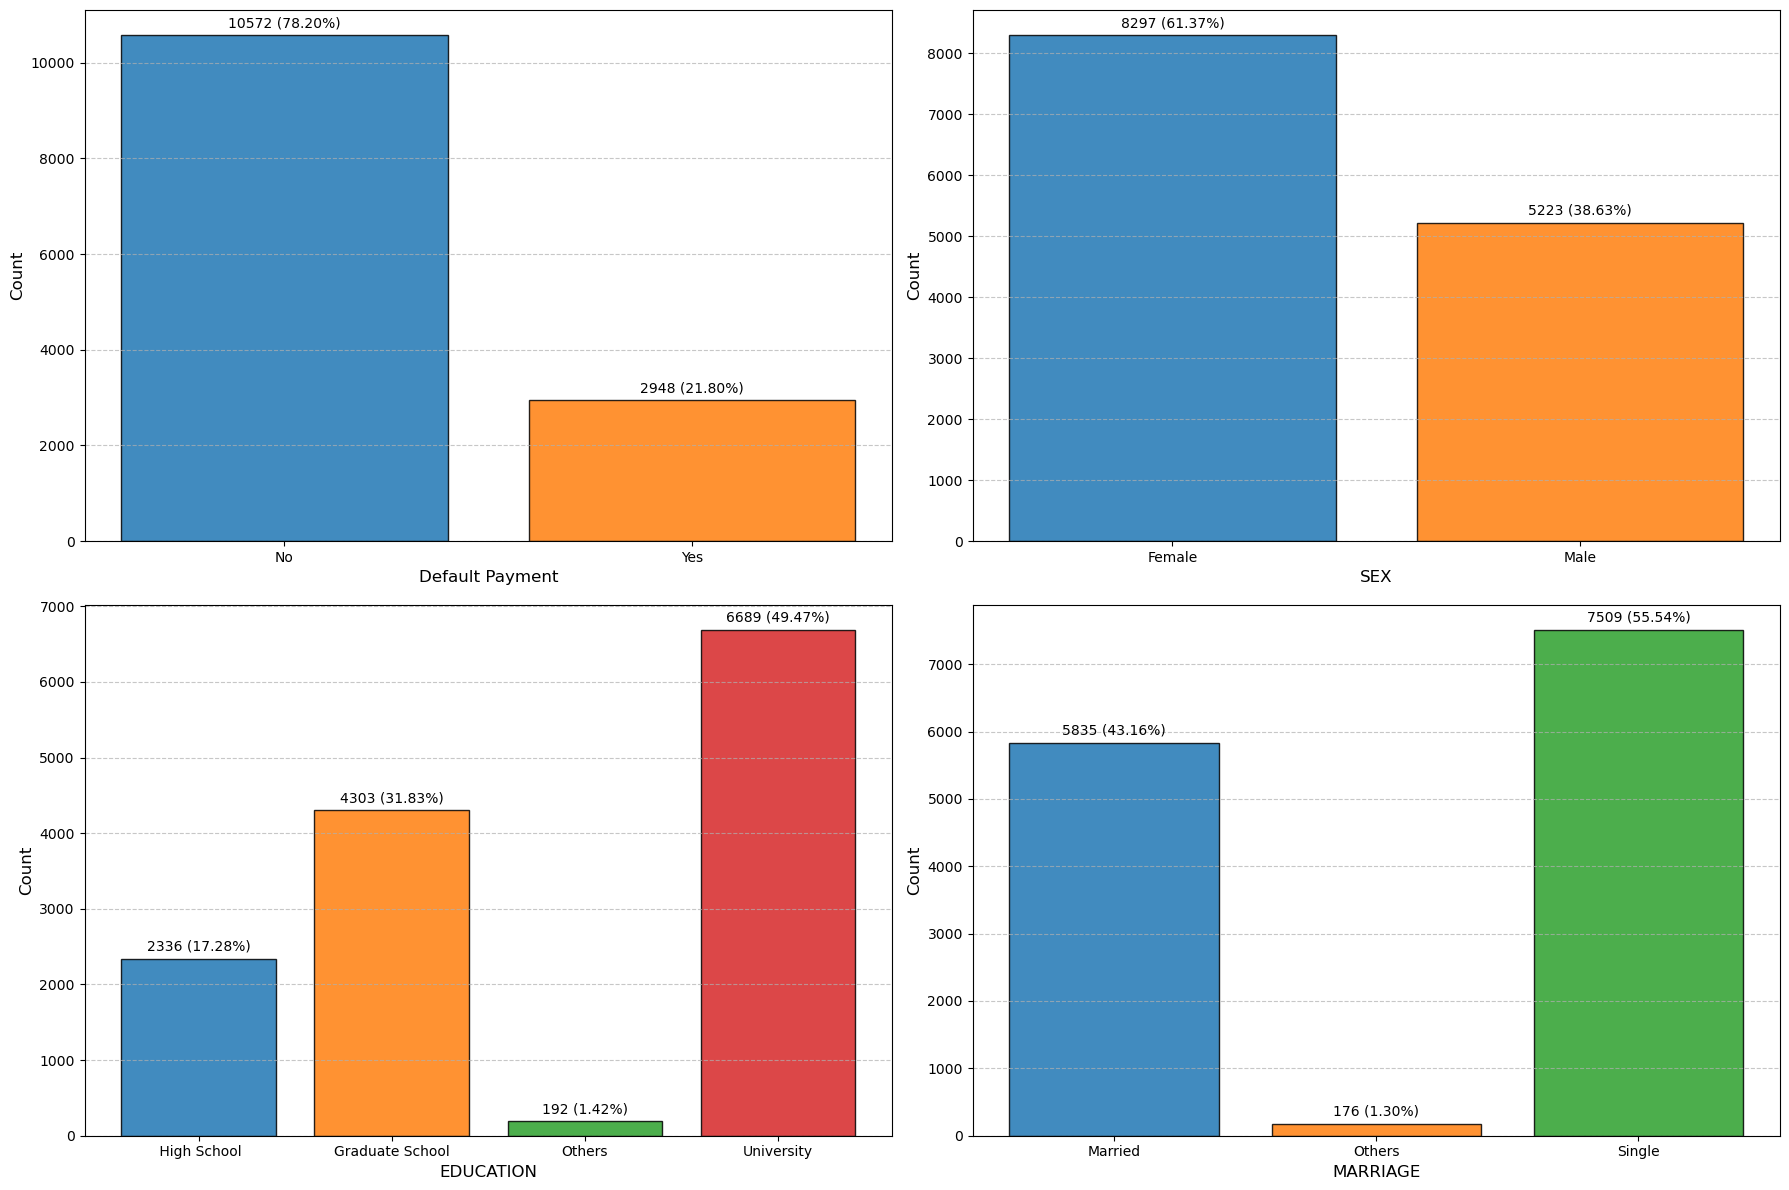

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the features as they appear exactly in the dataset
features = ['Default Payment', 'SEX', 'EDUCATION', 'MARRIAGE']

# Create a figure with 2 rows and 2 columns for bar charts
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Generate bar charts for each feature
for ax, feature in zip(axes, features):
    counts = df_db_clean[feature].value_counts().sort_index()
    percentages = df_db_clean[feature].value_counts(normalize=True).sort_index() * 100

    # Choose a colormap and get a color for each bar
    cmap = plt.get_cmap('tab10')  # 'tab10', 'Set2', 'Accent', etc. all work well
    colors = [cmap(i) for i in range(len(counts))]

    bars = ax.bar(counts.index.astype(str), counts, color=colors, alpha=0.85, edgecolor='black')

    # Annotate bars with count and percentage
    for bar, count, pct in zip(bars, counts, percentages):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts)*0.01,
            f'{int(count)} ({pct:.2f}%)',
            ha='center', va='bottom', fontsize=10
        )

    #ax.set_title(feature, fontsize=14)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [ ]:
# Save to CSV
# Save the test set predictions to CSV
df_db_clean.to_csv('DBSCAN.csv', index=False)

# Analysis Using Borutta_DBSCAN Data

# SMOTE Analysis

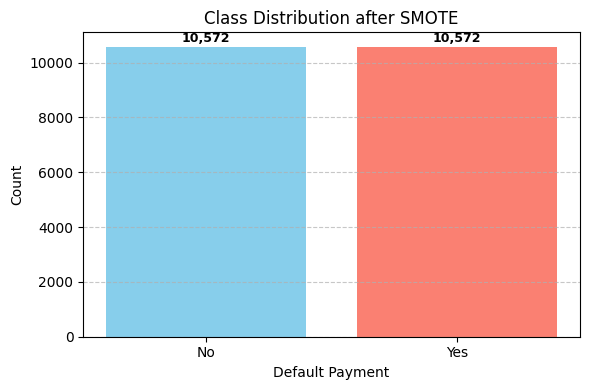

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from imblearn.over_sampling import SMOTE
df= pd.read_csv("/content/Borutta_DBSCAN.csv")

# Convert target to numeric
df['Default Payment'] = df['Default Payment'].map({'No': 0, 'Yes': 1})

# Separate features and target
X = df.drop('Default Payment', axis=1)
y = df['Default Payment']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

# Check new class distribution
pd.Series(y_smote).value_counts()

# Step 5: Bar chart of new class distribution
# Get class distribution after SMOTE
smote_counts = pd.Series(y_smote).value_counts().sort_index()
smote_counts.index = ['No', 'Yes']

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(smote_counts.index, smote_counts, color=['skyblue', 'salmon'])
plt.title('Class Distribution after SMOTE')
plt.xlabel('Default Payment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:,}',  # Comma as thousands separator
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 1),  # 5 points vertical offset
                 textcoords='offset points',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

# Logistic Regression

Best Hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Time to train (seconds): 65.18

Train Metrics:
Accuracy: 0.6539
Recall: 0.7339
Specificity: 0.5738
F1-Score: 0.6795
AUC: 0.7022
G-mean: 0.6489
Fbeta-Measure (beta=2): 0.7111

Test Metrics:
Accuracy: 0.6493
Recall: 0.7209
Specificity: 0.5778
F1-Score: 0.6727
AUC: 0.6940
G-mean: 0.6454
Fbeta-Measure (beta=2): 0.7008


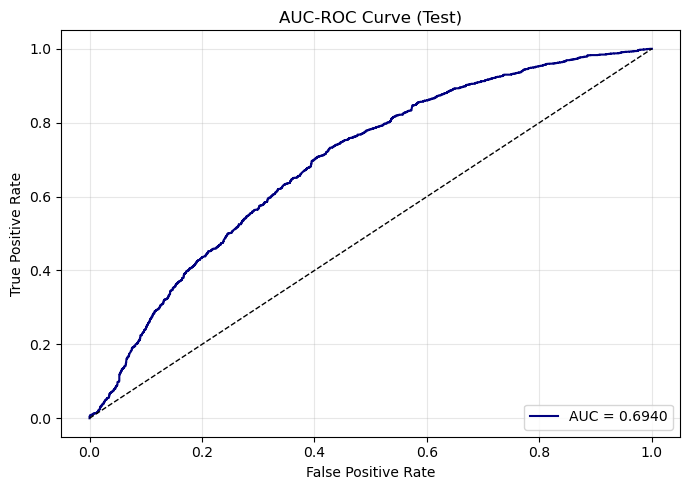

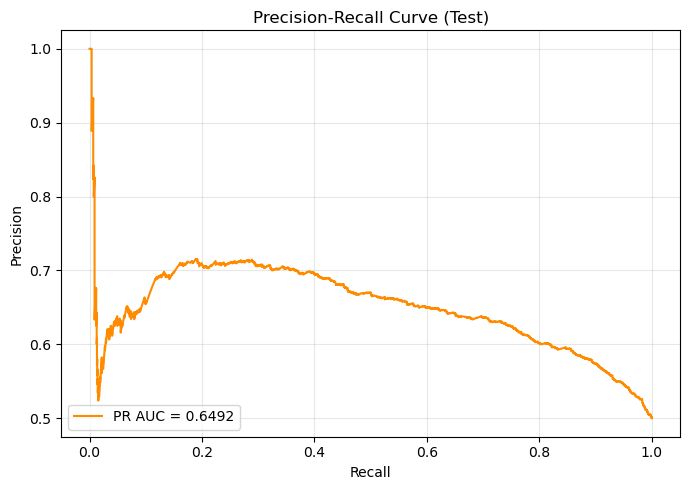

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

# 4. Logistic Regression with GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

scorer = make_scorer(f1_score)
logreg = LogisticRegression(max_iter=1000, random_state=42)

start_time = time.time()
clf = GridSearchCV(logreg, param_grid, cv=5, scoring=scorer, n_jobs=-1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Naive Bayes

Best Hyperparameters: {'var_smoothing': np.float64(1e-11)}
Time to train (seconds): 4.66

Train Metrics:
Accuracy: 0.5986
Recall: 0.8639
Specificity: 0.3333
F1-Score: 0.6828
AUC: 0.6697
G-mean: 0.5366
Fbeta-Measure (beta=2): 0.7810

Test Metrics:
Accuracy: 0.5933
Recall: 0.8538
Specificity: 0.3329
F1-Score: 0.6773
AUC: 0.6618
G-mean: 0.5331
Fbeta-Measure (beta=2): 0.7732


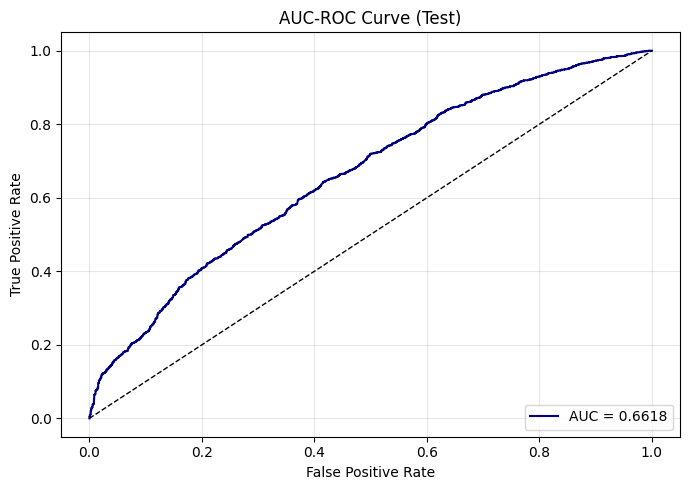

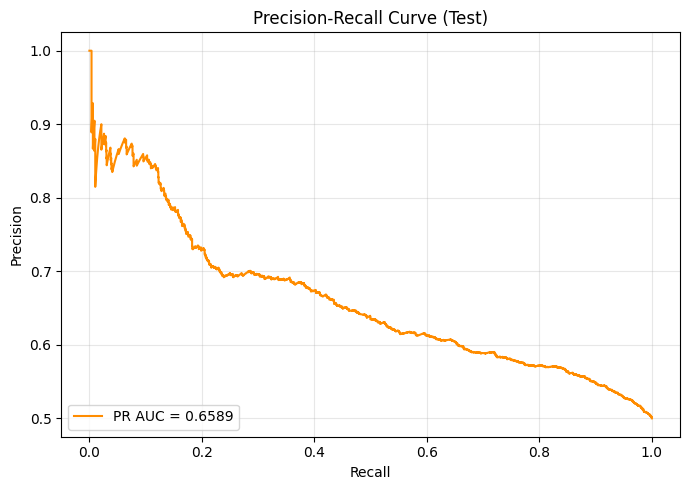

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

# 4. Naive Bayes with GridSearchCV (tuning var_smoothing)
param_grid = {
    'var_smoothing': np.logspace(-11, -7, 5)  # Example: [1e-11, 1e-10, ..., 1e-7]
}

scorer = make_scorer(f1_score)
nb = GaussianNB()

start_time = time.time()
clf = GridSearchCV(nb, param_grid, cv=5, scoring=scorer, n_jobs=-1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# K-NN

Best Hyperparameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Time to train (seconds): 118.00

Train Metrics:
Accuracy: 0.9789
Recall: 0.9836
Specificity: 0.9742
F1-Score: 0.9790
AUC: 0.9949
G-mean: 0.9789
Fbeta-Measure (beta=2): 0.9817

Test Metrics:
Accuracy: 0.7886
Recall: 0.9120
Specificity: 0.6652
F1-Score: 0.8118
AUC: 0.8579
G-mean: 0.7789
Fbeta-Measure (beta=2): 0.8691


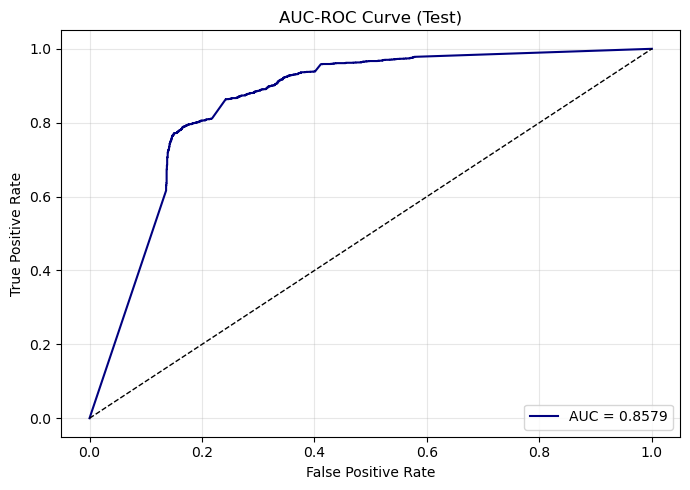

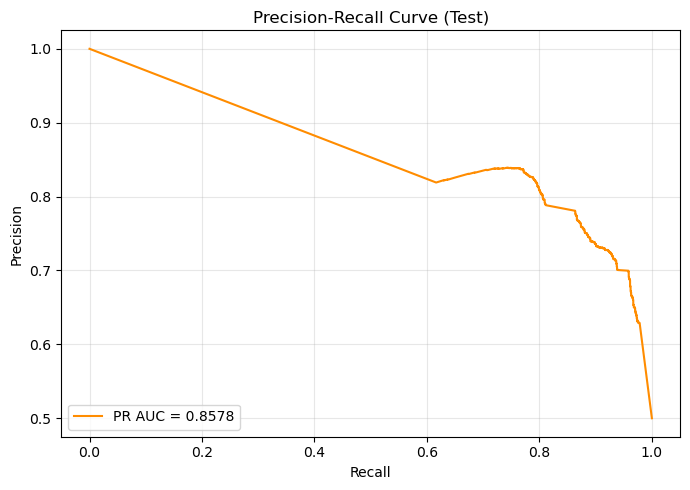

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

# 4. K-NN with GridSearchCV (tuning n_neighbors, weights, metric)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

scorer = make_scorer(f1_score)
knn = KNeighborsClassifier()

start_time = time.time()
clf = GridSearchCV(knn, param_grid, cv=5, scoring=scorer, n_jobs=-1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# XGBoost

Fitting 5 folds for each of 192 candidates, totalling 960 fits
Best Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Time to train (seconds): 87.67

Train Metrics:
Accuracy: 0.8326
Recall: 0.8091
Specificity: 0.8562
F1-Score: 0.8286
AUC: 0.9154
G-mean: 0.8323
Fbeta-Measure (beta=2): 0.8168

Test Metrics:
Accuracy: 0.8000
Recall: 0.7673
Specificity: 0.8326
F1-Score: 0.7932
AUC: 0.8795
G-mean: 0.7993
Fbeta-Measure (beta=2): 0.7774


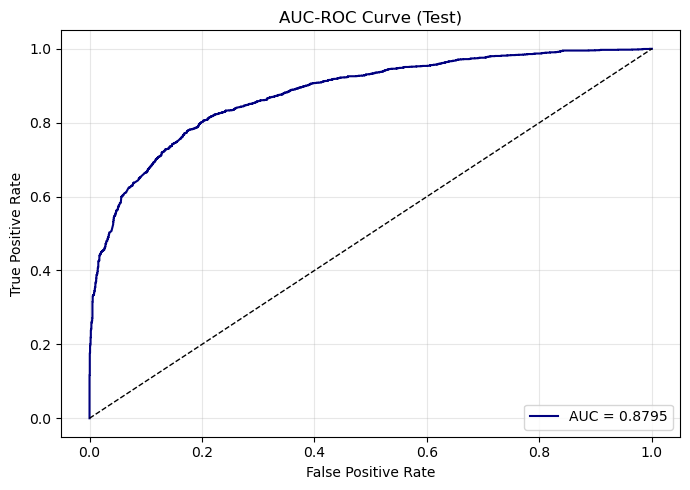

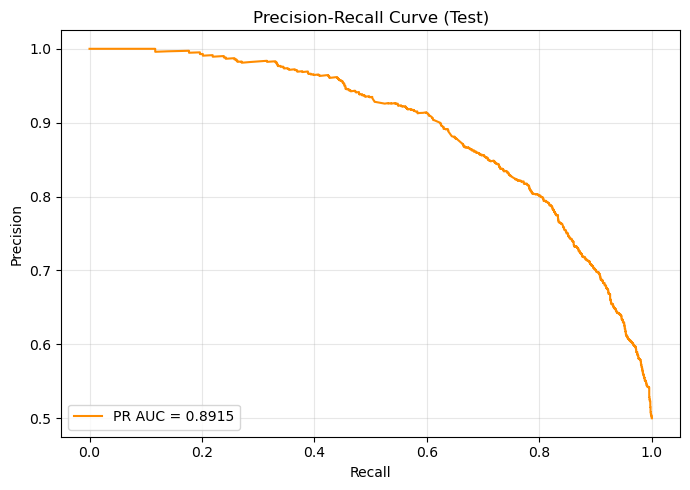

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

# 4. XGBoost with GridSearchCV (expanded params)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2,3,4,5],
    'learning_rate': [0.001, 0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1]
}

scorer = make_scorer(f1_score)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

start_time = time.time()
clf = GridSearchCV(xgb, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Adaboost

Fitting 5 folds for each of 18 candidates, totalling 90 fits


C:\Users\edmun\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Best Hyperparameters: {'algorithm': 'SAMME.R', 'learning_rate': 1.0, 'n_estimators': 200}
Time to train (seconds): 89.75

Train Metrics:
Accuracy: 0.7728
Recall: 0.7309
Specificity: 0.8147
F1-Score: 0.7629
AUC: 0.8623
G-mean: 0.7717
Fbeta-Measure (beta=2): 0.7434

Test Metrics:
Accuracy: 0.7699
Recall: 0.7275
Specificity: 0.8123
F1-Score: 0.7597
AUC: 0.8476
G-mean: 0.7687
Fbeta-Measure (beta=2): 0.7401


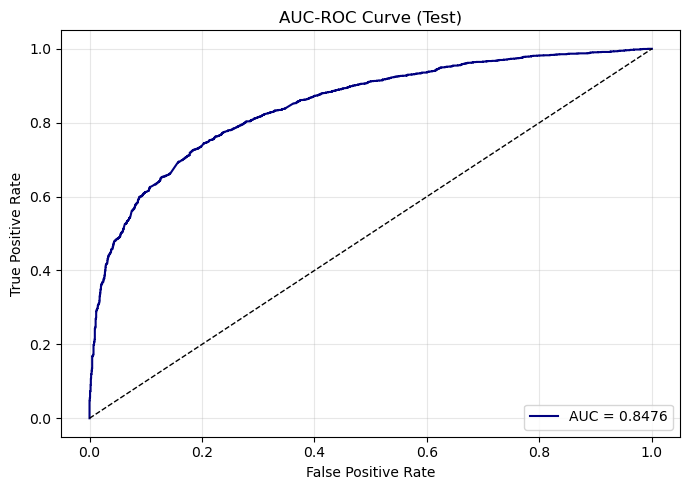

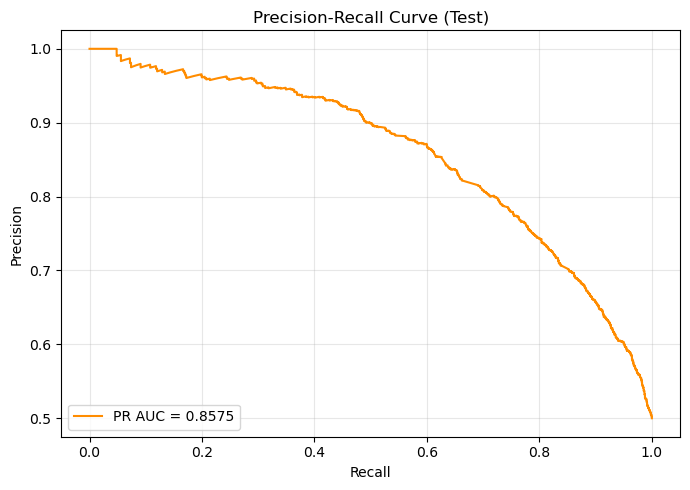

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

# 4. AdaBoost with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'algorithm': ['SAMME', 'SAMME.R']
}

scorer = make_scorer(f1_score)
ada = AdaBoostClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(ada, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# GBM

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 100, 'subsample': 1.0}
Time to train (seconds): 1183.85

Train Metrics:
Accuracy: 0.8932
Recall: 0.8897
Specificity: 0.8968
F1-Score: 0.8929
AUC: 0.9640
G-mean: 0.8932
Fbeta-Measure (beta=2): 0.8910

Test Metrics:
Accuracy: 0.8222
Recall: 0.7961
Specificity: 0.8482
F1-Score: 0.8174
AUC: 0.8973
G-mean: 0.8218
Fbeta-Measure (beta=2): 0.8045


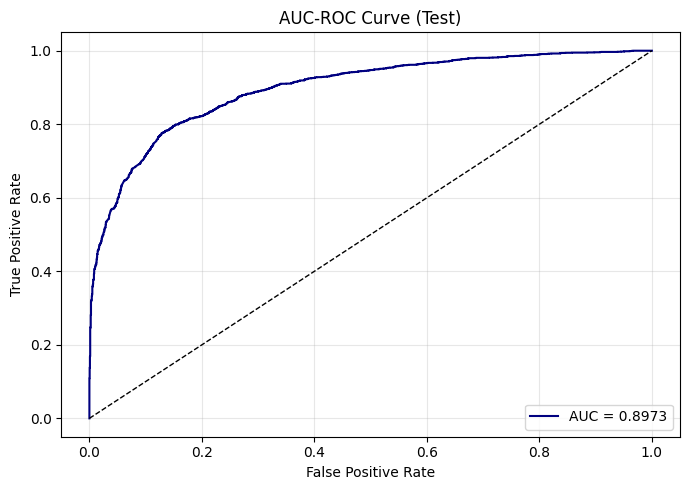

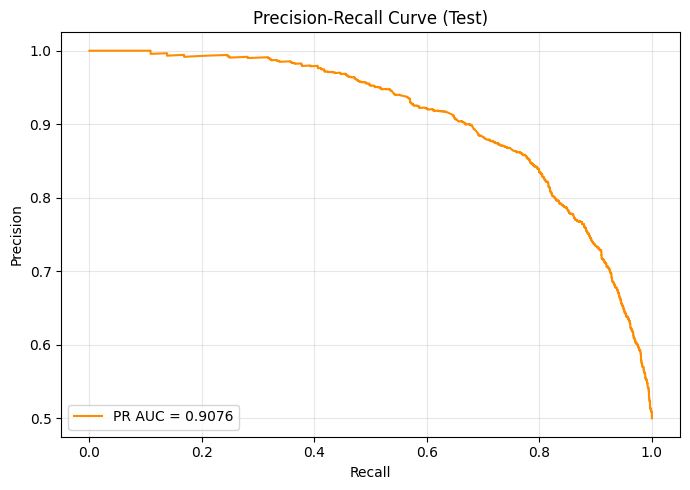

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
                            precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

# 4. Gradient Boosting with GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.001,0.01, 0.1],
    'max_depth': [3, 5,7],
    'subsample': [0.5, 1.0],
    'max_features': [None, 'sqrt']
}

scorer = make_scorer(f1_score)
gbm = GradientBoostingClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(gbm, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# LightGBM

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[LightGBM] [Info] Number of positive: 8458, number of negative: 8457
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000596 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3316
[LightGBM] [Info] Number of data points in the train set: 16915, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500030 -> initscore=0.000118
[LightGBM] [Info] Start training from score 0.000118
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best Hyperparameters: {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'num_leaves': 20, 'subsample': 0.5}
Time to train (seconds): 301.84

Train Metrics:
Accuracy: 0.8314
Recall: 0.8072
Specifici

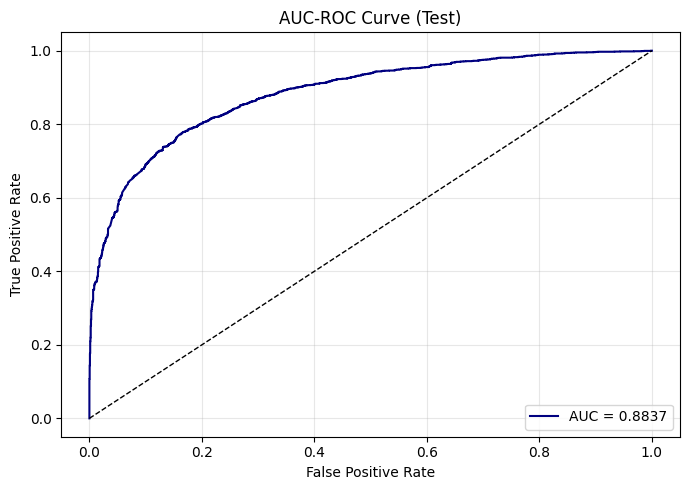

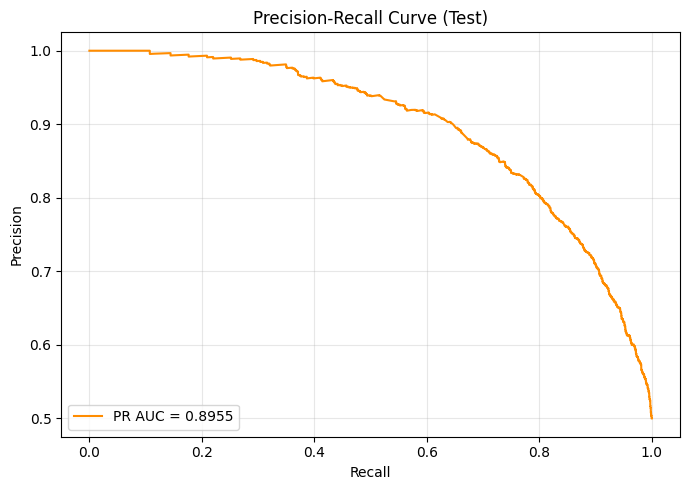

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

# 4. LightGBM with GridSearchCV (expanded params)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5,7],
    'learning_rate': [0.001,0.01, 0.1],
    'num_leaves': [5,10,15,20],
    'subsample': [0.5, 1.0],
    'colsample_bytree': [0.5, 1.0]
}

scorer = make_scorer(f1_score)
lgbm = LGBMClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(lgbm, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# SMOTE-TOMEK Analysis

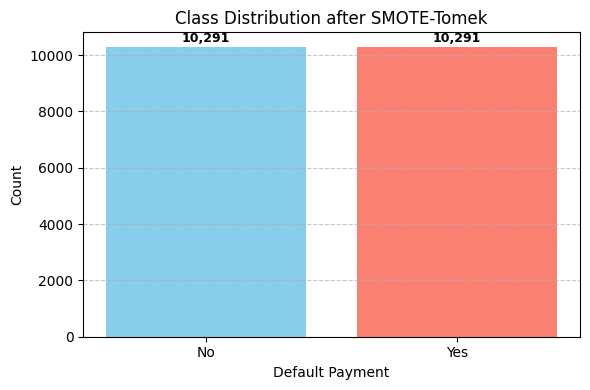

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from imblearn.combine import SMOTETomek

df = pd.read_csv("/content/Borutta_DBSCAN.csv")

# Convert target to numeric
df['Default Payment'] = df['Default Payment'].map({'No': 0, 'Yes': 1})

# Separate features and target
X = df.drop('Default Payment', axis=1)
y = df['Default Payment']

# Apply SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_smotetomek, y_smotetomek = smote_tomek.fit_resample(X, y)

# Check new class distribution
smotetomek_counts = pd.Series(y_smotetomek).value_counts().sort_index()
smotetomek_counts.index = ['No', 'Yes']

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(smotetomek_counts.index, smotetomek_counts, color=['skyblue', 'salmon'])
plt.title('Class Distribution after SMOTE-Tomek')
plt.xlabel('Default Payment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:,}',  # Comma as thousands separator
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 1),  # 1 point vertical offset
                 textcoords='offset points',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

# Naive Bayes

Best Hyperparameters: {'var_smoothing': np.float64(1e-11)}
Time to train (seconds): 0.73

Train Metrics:
Accuracy: 0.5974
Recall: 0.8612
Specificity: 0.3337
F1-Score: 0.6815
AUC: 0.6678
G-mean: 0.5361
Fbeta-Measure (beta=2): 0.7790

Test Metrics:
Accuracy: 0.6131
Recall: 0.8717
Specificity: 0.3545
F1-Score: 0.6925
AUC: 0.6859
G-mean: 0.5559
Fbeta-Measure (beta=2): 0.7900


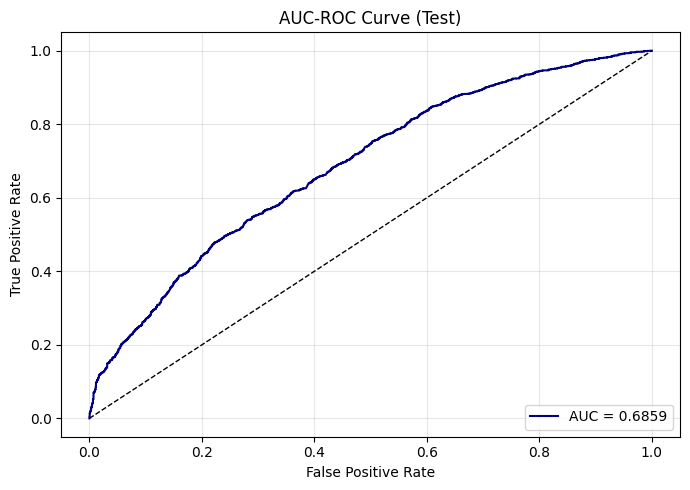

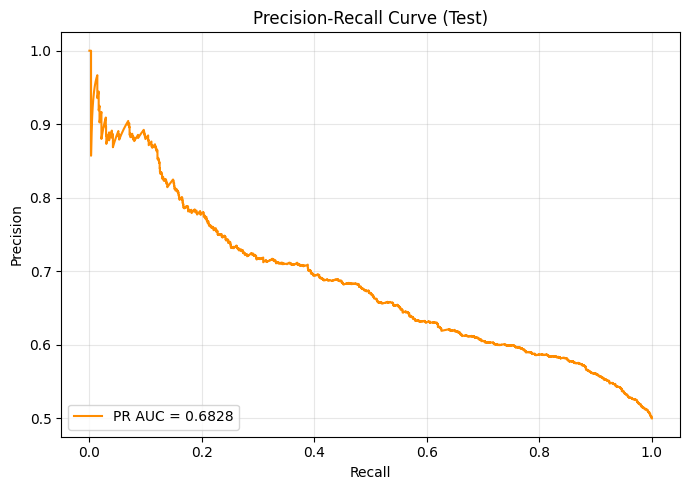

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smotetomek, y_smotetomek, test_size=0.2, random_state=42, stratify=y_smotetomek
)

# 4. Naive Bayes with GridSearchCV (tuning var_smoothing)
param_grid = {
    'var_smoothing': np.logspace(-11, -7, 5)  # Example: [1e-11, 1e-10, ..., 1e-7]
}

scorer = make_scorer(f1_score)
nb = GaussianNB()

start_time = time.time()
clf = GridSearchCV(nb, param_grid, cv=5, scoring=scorer, n_jobs=-1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# K-NN

Best Hyperparameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Time to train (seconds): 138.07

Train Metrics:
Accuracy: 0.9755
Recall: 0.9721
Specificity: 0.9789
F1-Score: 0.9754
AUC: 0.9897
G-mean: 0.9755
Fbeta-Measure (beta=2): 0.9734

Test Metrics:
Accuracy: 0.7804
Recall: 0.9009
Specificity: 0.6600
F1-Score: 0.8040
AUC: 0.8574
G-mean: 0.7711
Fbeta-Measure (beta=2): 0.8594


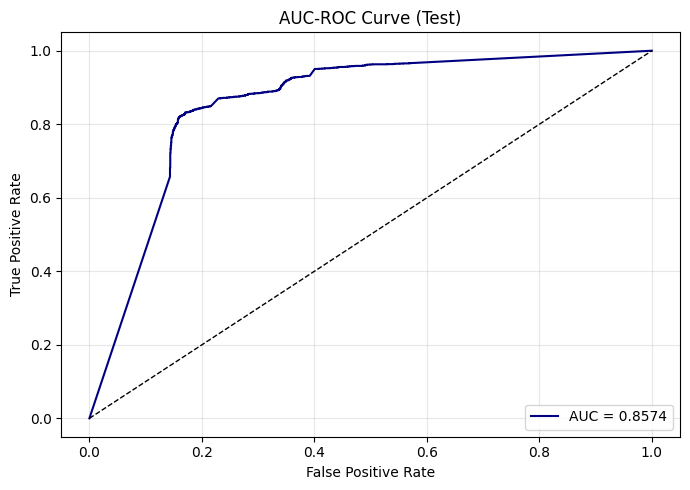

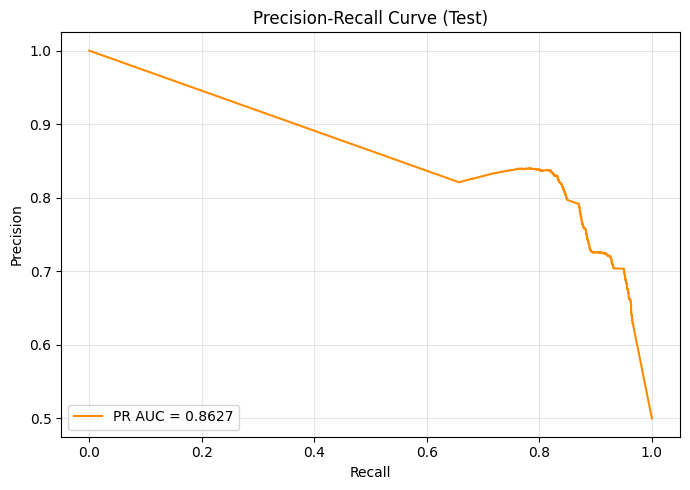

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smotetomek, y_smotetomek, test_size=0.2, random_state=42, stratify=y_smotetomek
)

# 4. K-NN with GridSearchCV (tuning n_neighbors, weights, metric)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

scorer = make_scorer(f1_score)
knn = KNeighborsClassifier()

start_time = time.time()
clf = GridSearchCV(knn, param_grid, cv=5, scoring=scorer, n_jobs=-1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# XGBoost

Fitting 5 folds for each of 192 candidates, totalling 960 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:29:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Time to train (seconds): 282.60

Train Metrics:
Accuracy: 0.8360
Recall: 0.8109
Specificity: 0.8612
F1-Score: 0.8318
AUC: 0.9181
G-mean: 0.8356
Fbeta-Measure (beta=2): 0.8191

Test Metrics:
Accuracy: 0.8132
Recall: 0.7755
Specificity: 0.8509
F1-Score: 0.8059
AUC: 0.8911
G-mean: 0.8123
Fbeta-Measure (beta=2): 0.7874


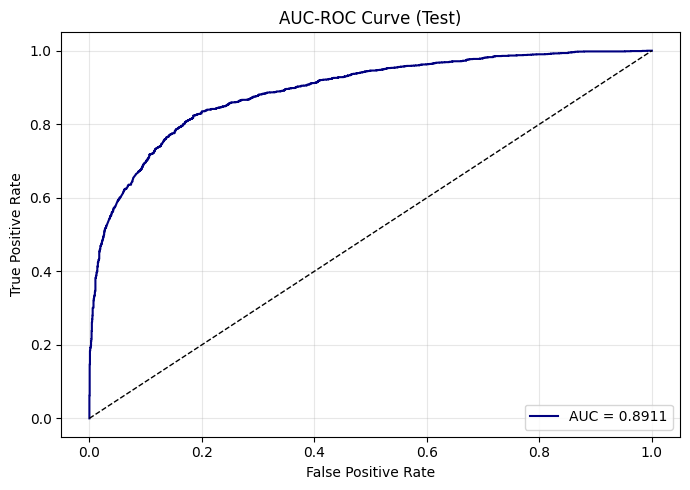

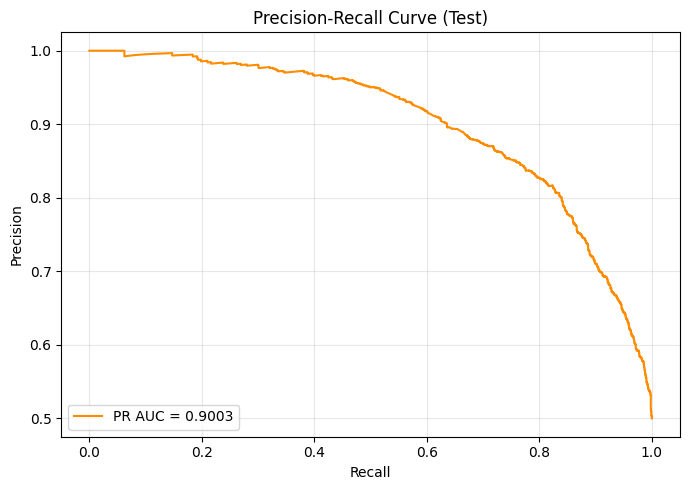

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smotetomek, y_smotetomek, test_size=0.2, random_state=42, stratify=y_smotetomek
)

# 4. XGBoost with GridSearchCV (expanded params)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2,3,4,5],
    'learning_rate': [0.001, 0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1]
}

scorer = make_scorer(f1_score)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

start_time = time.time()
clf = GridSearchCV(xgb, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AdaBoost

Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_

Best Hyperparameters: {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 200}
Time to train (seconds): 136.17

Train Metrics:
Accuracy: 0.7560
Recall: 0.6988
Specificity: 0.8133
F1-Score: 0.7412
AUC: 0.8303
G-mean: 0.7539
Fbeta-Measure (beta=2): 0.7152

Test Metrics:
Accuracy: 0.7603
Recall: 0.6992
Specificity: 0.8213
F1-Score: 0.7446
AUC: 0.8322
G-mean: 0.7578
Fbeta-Measure (beta=2): 0.7167


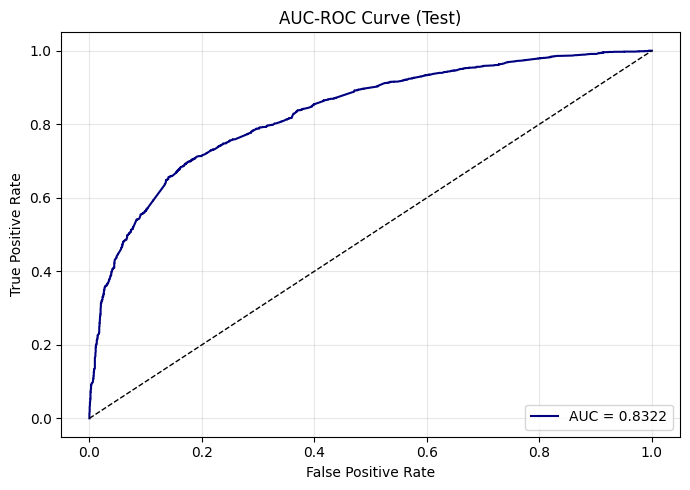

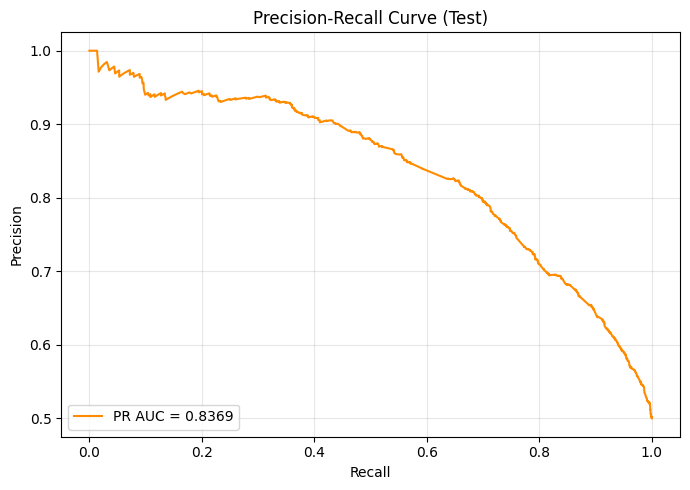

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smotetomek, y_smotetomek, test_size=0.2, random_state=42, stratify=y_smotetomek
)

# 4. AdaBoost with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'algorithm': ['SAMME', 'SAMME.R']
}

scorer = make_scorer(f1_score)
ada = AdaBoostClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(ada, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# GBM

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'max_features': None, 'n_estimators': 150, 'subsample': 0.5}
Time to train (seconds): 2482.81

Train Metrics:
Accuracy: 0.9263
Recall: 0.9259
Specificity: 0.9266
F1-Score: 0.9262
AUC: 0.9810
G-mean: 0.9263
Fbeta-Measure (beta=2): 0.9260

Test Metrics:
Accuracy: 0.8302
Recall: 0.8042
Specificity: 0.8562
F1-Score: 0.8256
AUC: 0.9090
G-mean: 0.8298
Fbeta-Measure (beta=2): 0.8126


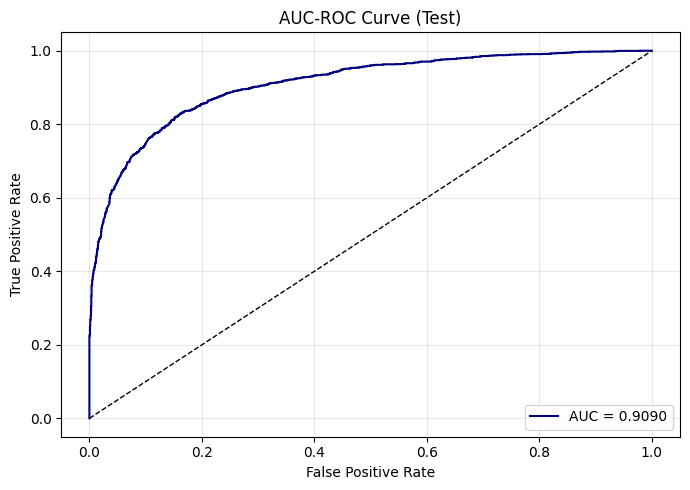

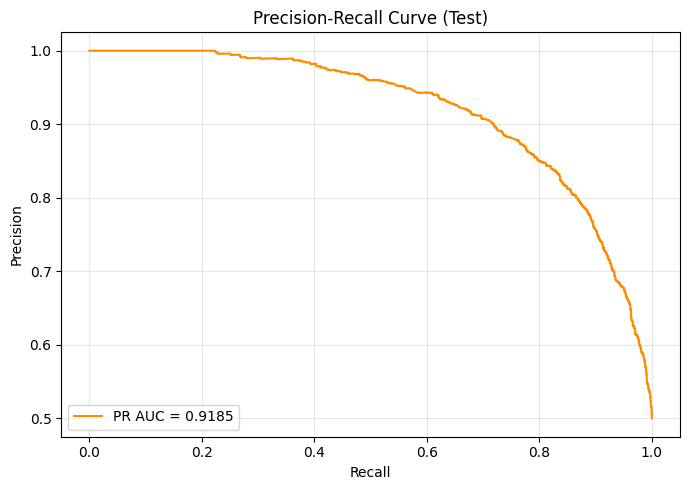

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
                            precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smotetomek, y_smotetomek, test_size=0.2, random_state=42, stratify=y_smotetomek
)

# 4. Gradient Boosting with GridSearchCV
param_grid = {
    'n_estimators': [50, 100,150],
    'learning_rate': [0.001,0.01, 0.1],
    'max_depth': [3, 5,7],
    'subsample': [0.5, 1.0],
    'max_features': [None, 'sqrt']
}

scorer = make_scorer(f1_score)
gbm = GradientBoostingClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(gbm, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# LightGBM

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[LightGBM] [Info] Number of positive: 8233, number of negative: 8232
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3306
[LightGBM] [Info] Number of data points in the train set: 16465, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500030 -> initscore=0.000121
[LightGBM] [Info] Start training from score 0.000121
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'num_leaves': 20, 'subsample': 0.5}
Time to train (seconds): 323.25

Train Metrics:
Accuracy: 0.8380
Recall: 0.8171
Specifici

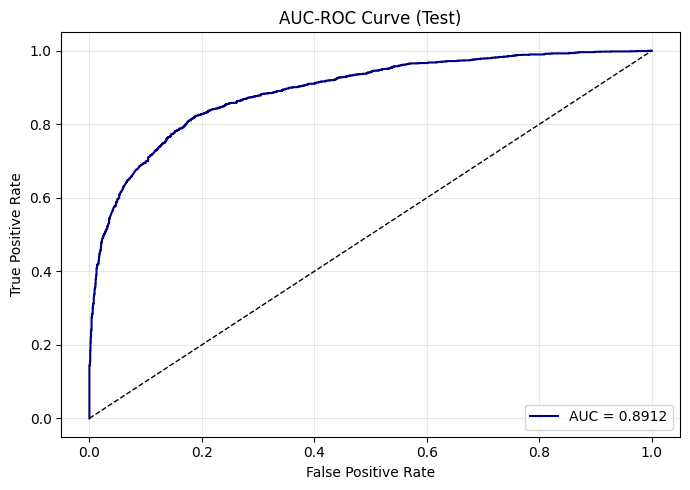

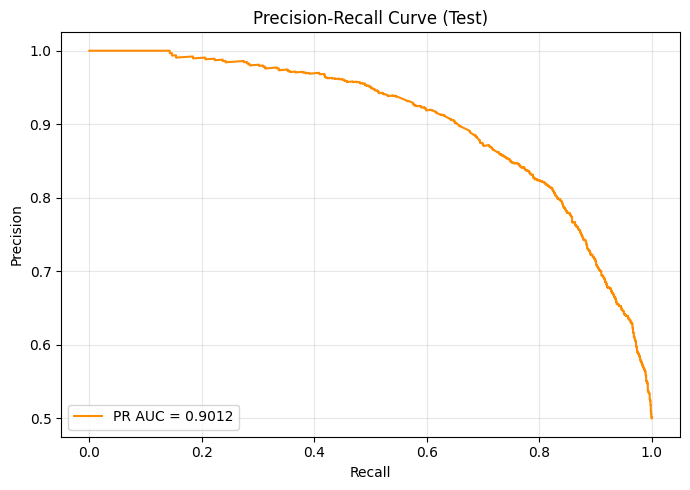

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_smotetomek, y_smotetomek, test_size=0.2, random_state=42, stratify=y_smotetomek
)

# 4. LightGBM with GridSearchCV (expanded params)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5,7],
    'learning_rate': [0.001,0.01, 0.1],
    'num_leaves': [5,10,15,20],
    'subsample': [0.5, 1.0],
    'colsample_bytree': [0.5, 1.0]
}

scorer = make_scorer(f1_score)
lgbm = LGBMClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(lgbm, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ADASYN Analysis

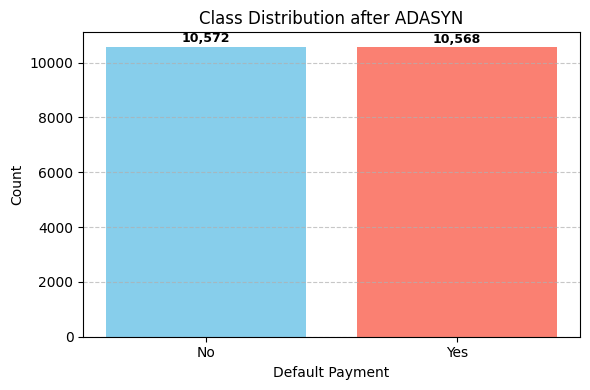

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from imblearn.over_sampling import ADASYN

df = pd.read_csv("/content/Borutta_DBSCAN.csv")

# Convert target to numeric
df['Default Payment'] = df['Default Payment'].map({'No': 0, 'Yes': 1})

# Separate features and target
X = df.drop('Default Payment', axis=1)
y = df['Default Payment']

# Apply ADASYN
adasyn = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn.fit_resample(X, y)

# Check new class distribution
adasyn_counts = pd.Series(y_adasyn).value_counts().sort_index()
adasyn_counts.index = ['No', 'Yes']

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(adasyn_counts.index, adasyn_counts, color=['skyblue', 'salmon'])
plt.title('Class Distribution after ADASYN')
plt.xlabel('Default Payment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:,}',  # Comma as thousands separator
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 1),  # 1 point vertical offset
                 textcoords='offset points',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

# Naive Bayes

Best Hyperparameters: {'var_smoothing': np.float64(1e-11)}
Time to train (seconds): 0.60

Train Metrics:
Accuracy: 0.5864
Recall: 0.8552
Specificity: 0.3177
F1-Score: 0.6740
AUC: 0.6574
G-mean: 0.5212
Fbeta-Measure (beta=2): 0.7722

Test Metrics:
Accuracy: 0.5873
Recall: 0.8524
Specificity: 0.3221
F1-Score: 0.6738
AUC: 0.6514
G-mean: 0.5240
Fbeta-Measure (beta=2): 0.7707


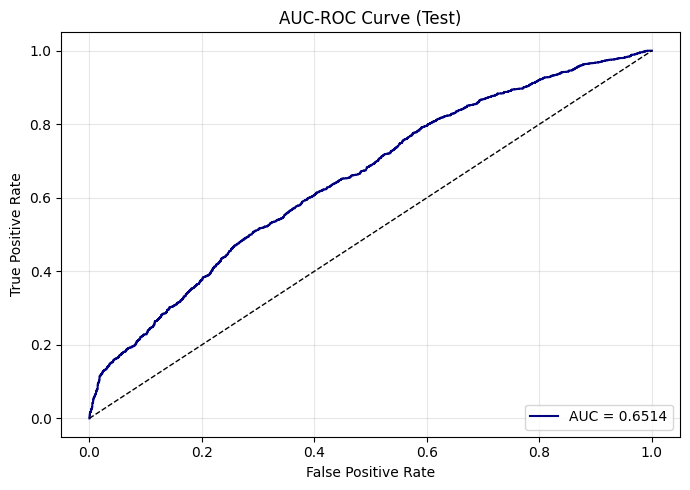

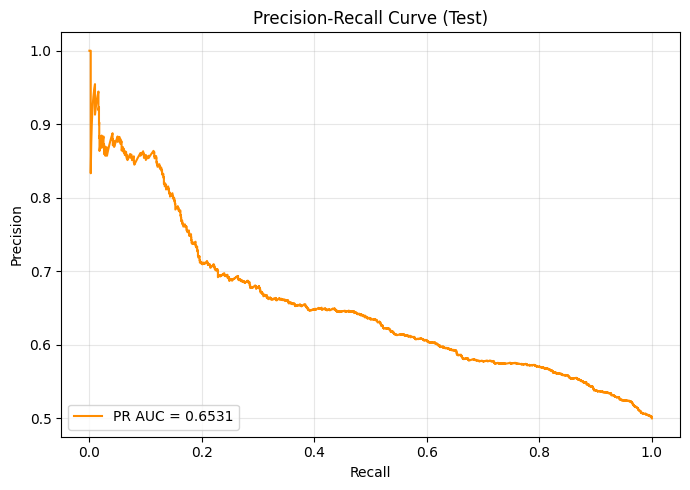

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_adasyn, y_adasyn, test_size=0.2, random_state=42, stratify=y_adasyn
)

# 4. Naive Bayes with GridSearchCV (tuning var_smoothing)
param_grid = {
    'var_smoothing': np.logspace(-11, -7, 5)  # Example: [1e-11, 1e-10, ..., 1e-7]
}

scorer = make_scorer(f1_score)
nb = GaussianNB()

start_time = time.time()
clf = GridSearchCV(nb, param_grid, cv=5, scoring=scorer, n_jobs=-1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# K-NN

Best Hyperparameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Time to train (seconds): 127.44

Train Metrics:
Accuracy: 0.9788
Recall: 0.9824
Specificity: 0.9752
F1-Score: 0.9788
AUC: 0.9904
G-mean: 0.9788
Fbeta-Measure (beta=2): 0.9810

Test Metrics:
Accuracy: 0.7774
Recall: 0.9210
Specificity: 0.6339
F1-Score: 0.8054
AUC: 0.8483
G-mean: 0.7641
Fbeta-Measure (beta=2): 0.8710


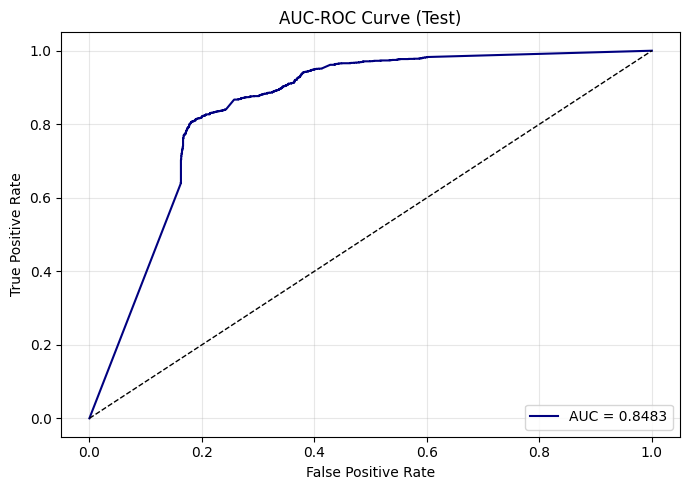

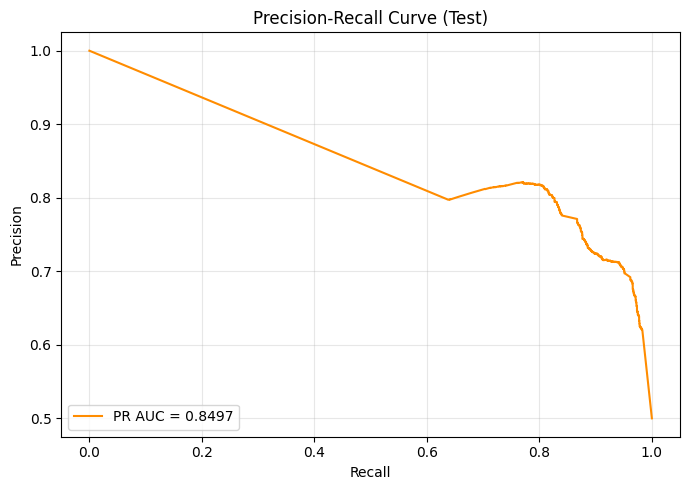

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_adasyn, y_adasyn, test_size=0.2, random_state=42, stratify=y_adasyn
)

# 4. K-NN with GridSearchCV (tuning n_neighbors, weights, metric)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

scorer = make_scorer(f1_score)
knn = KNeighborsClassifier()

start_time = time.time()
clf = GridSearchCV(knn, param_grid, cv=5, scoring=scorer, n_jobs=-1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# XGBoost

Fitting 5 folds for each of 192 candidates, totalling 960 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:29:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Time to train (seconds): 224.77

Train Metrics:
Accuracy: 0.8245
Recall: 0.7948
Specificity: 0.8542
F1-Score: 0.8191
AUC: 0.9130
G-mean: 0.8240
Fbeta-Measure (beta=2): 0.8043

Test Metrics:
Accuracy: 0.7916
Recall: 0.7512
Specificity: 0.8321
F1-Score: 0.7828
AUC: 0.8751
G-mean: 0.7906
Fbeta-Measure (beta=2): 0.7635


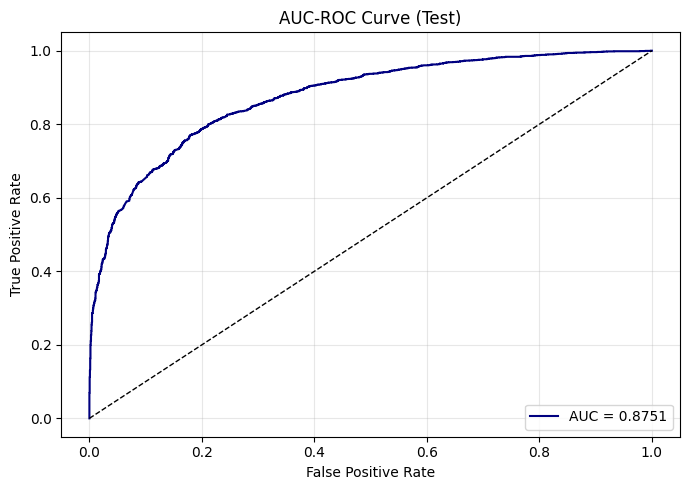

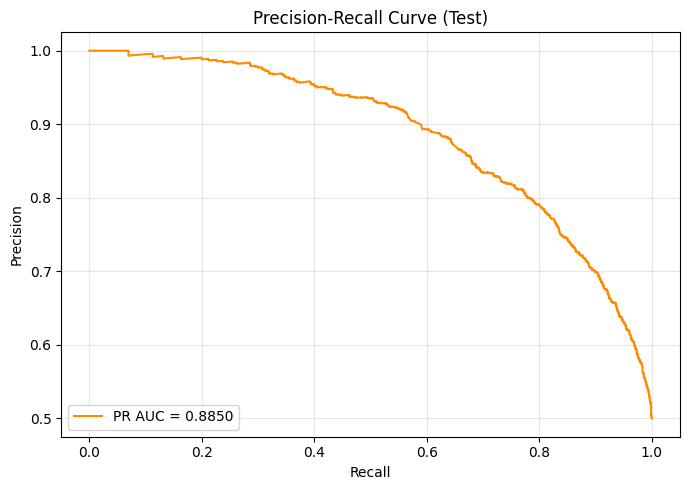

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_adasyn, y_adasyn, test_size=0.2, random_state=42, stratify=y_adasyn
)

# 4. XGBoost with GridSearchCV (expanded params)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2,3,4,5],
    'learning_rate': [0.001, 0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1]
}

scorer = make_scorer(f1_score)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

start_time = time.time()
clf = GridSearchCV(xgb, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AdaBoost

Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_

Best Hyperparameters: {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 200}
Time to train (seconds): 124.22

Train Metrics:
Accuracy: 0.7496
Recall: 0.6859
Specificity: 0.8133
F1-Score: 0.7326
AUC: 0.8233
G-mean: 0.7469
Fbeta-Measure (beta=2): 0.7039

Test Metrics:
Accuracy: 0.7465
Recall: 0.6774
Specificity: 0.8155
F1-Score: 0.7276
AUC: 0.8132
G-mean: 0.7433
Fbeta-Measure (beta=2): 0.6966


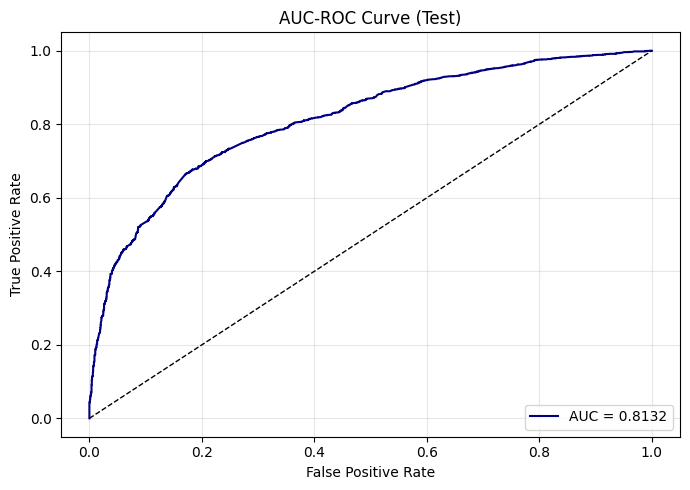

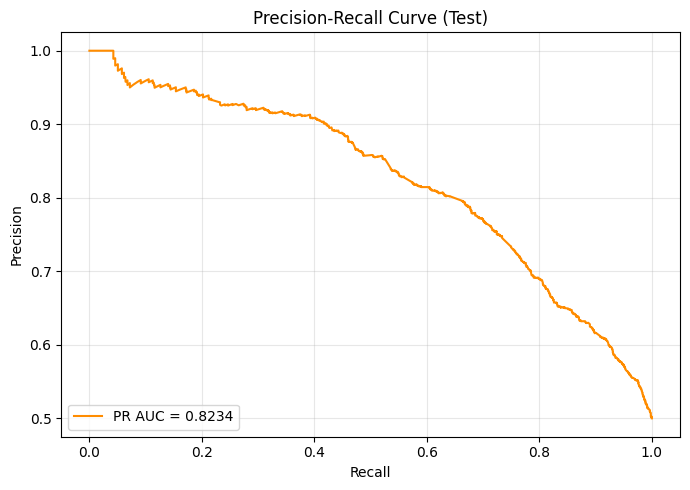

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_adasyn, y_adasyn, test_size=0.2, random_state=42, stratify=y_adasyn
)

# 4. AdaBoost with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'algorithm': ['SAMME', 'SAMME.R']
}

scorer = make_scorer(f1_score)
ada = AdaBoostClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(ada, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# GBM

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'max_features': None, 'n_estimators': 150, 'subsample': 1.0}
Time to train (seconds): 2398.40

Train Metrics:
Accuracy: 0.9259
Recall: 0.9252
Specificity: 0.9266
F1-Score: 0.9258
AUC: 0.9825
G-mean: 0.9259
Fbeta-Measure (beta=2): 0.9255

Test Metrics:
Accuracy: 0.8188
Recall: 0.7971
Specificity: 0.8406
F1-Score: 0.8148
AUC: 0.8972
G-mean: 0.8185
Fbeta-Measure (beta=2): 0.8041


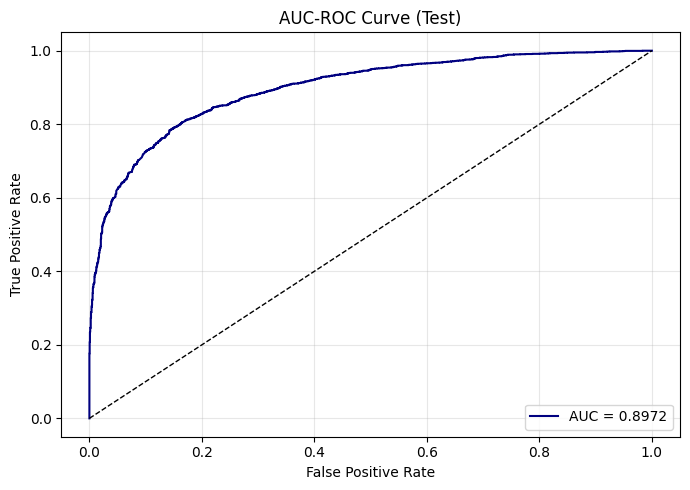

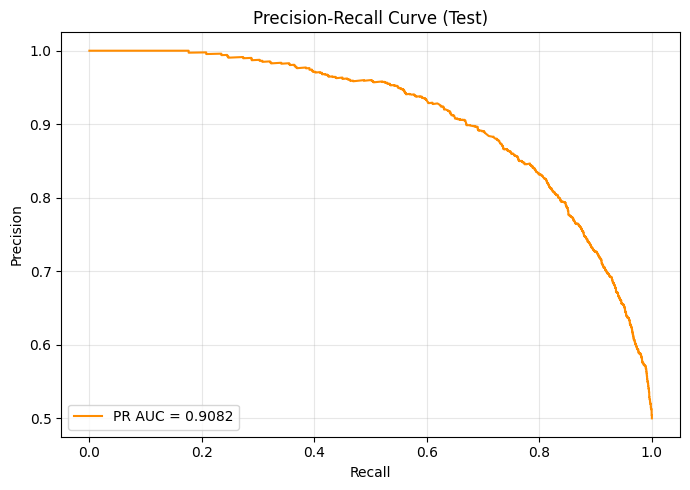

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
                            precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_adasyn, y_adasyn, test_size=0.2, random_state=42, stratify=y_adasyn
)

# 4. Gradient Boosting with GridSearchCV
param_grid = {
    'n_estimators': [50, 100,150],
    'learning_rate': [0.001,0.01, 0.1],
    'max_depth': [3, 5,7],
    'subsample': [0.5, 1.0],
    'max_features': [None, 'sqrt']
}

scorer = make_scorer(f1_score)
gbm = GradientBoostingClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(gbm, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# LightGBM

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[LightGBM] [Info] Number of positive: 8454, number of negative: 8458
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3322
[LightGBM] [Info] Number of data points in the train set: 16912, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499882 -> initscore=-0.000473
[LightGBM] [Info] Start training from score -0.000473
Best Hyperparameters: {'colsample_bytree': 0.5, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'num_leaves': 20, 'subsample': 0.5}
Time to train (seconds): 313.68

Train Metrics:
Accuracy: 0.8232
Recall: 0.7897
Specificity: 0.8567
F1-Score: 0.8170
AUC: 0.9112
G-mean: 0.8225
Fbeta-Measure (beta=2): 0.8004

Test Metrics:
Accuracy: 0.7949
Recall: 0.7498
Specificity: 0.

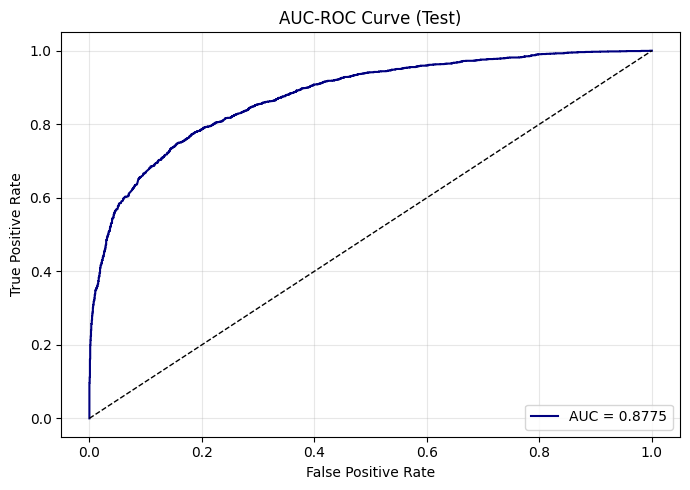

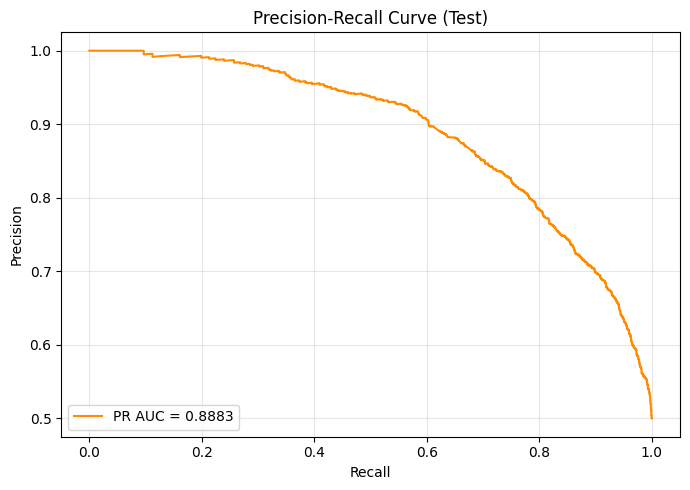

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_adasyn, y_adasyn, test_size=0.2, random_state=42, stratify=y_adasyn
)

# 4. LightGBM with GridSearchCV (expanded params)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5,7],
    'learning_rate': [0.001,0.01, 0.1],
    'num_leaves': [5,10,15,20],
    'subsample': [0.5, 1.0],
    'colsample_bytree': [0.5, 1.0]
}

scorer = make_scorer(f1_score)
lgbm = LGBMClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(lgbm, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AUC-ROC CURVE

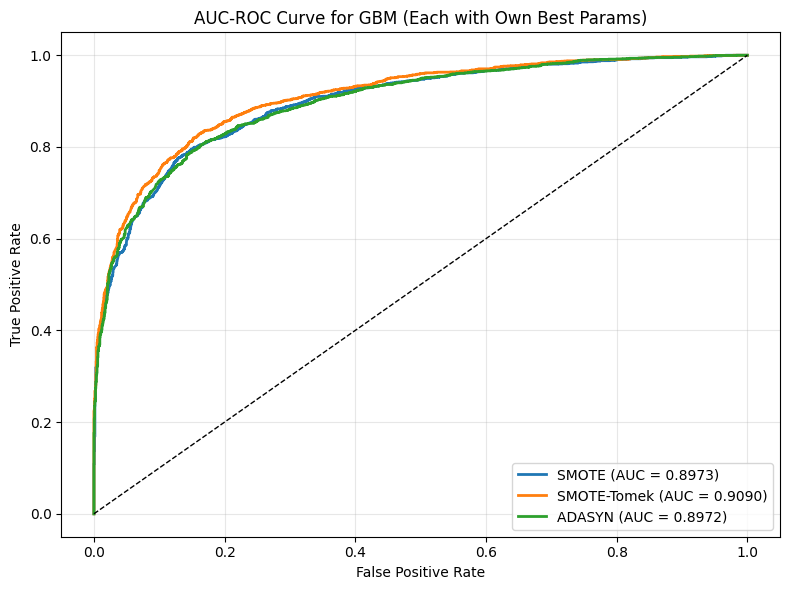

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/content/Borutta_DBSCAN.csv")
df['Default Payment'] = df['Default Payment'].map({'No': 0, 'Yes': 1})
X = df.drop('Default Payment', axis=1)
y = df['Default Payment']

# Define best parameters for each technique (replace with your actual results)
best_params_dict = {
    "SMOTE": {
        'n_estimators': 100,
        'learning_rate': 0.1,
        'max_depth': 7,
        'subsample': 1.0,
        'max_features': 'sqrt',
        'random_state': 42
    },
    "SMOTE-Tomek": {
        'n_estimators': 150,
        'learning_rate': 0.1,
        'max_depth': 7,
        'subsample': 0.5,
        'max_features': None,
        'random_state': 42
    },
    "ADASYN": {
        'n_estimators': 150,
        'learning_rate': 0.1,
        'max_depth': 7,
        'subsample': 1.0,
        'max_features': None,
        'random_state': 42
    }
}

samplers = {
    "SMOTE": SMOTE(random_state=42),
    "SMOTE-Tomek": SMOTETomek(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

plt.figure(figsize=(8, 6))

for name, sampler in samplers.items():
    params = best_params_dict[name]
    # Resample data
    X_res, y_res = sampler.fit_resample(X, y)
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
    )
    # Fit GBM with best params for that sampler
    gbm = GradientBoostingClassifier(**params)
    gbm.fit(X_train, y_train)
    y_prob = gbm.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve for GBM (Each with Own Best Params)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PR-AUC Curve

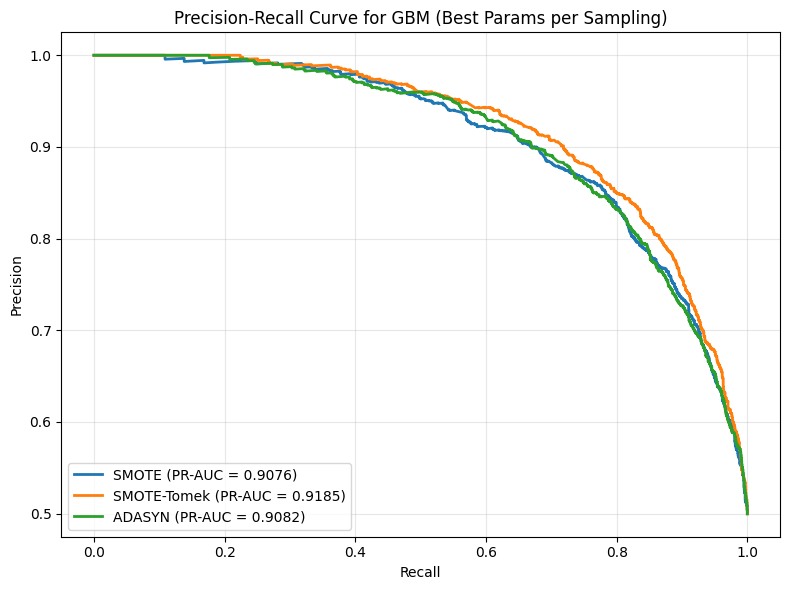

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_recall_curve, auc
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/content/Borutta_DBSCAN.csv")
df['Default Payment'] = df['Default Payment'].map({'No': 0, 'Yes': 1})
X = df.drop('Default Payment', axis=1)
y = df['Default Payment']

# Define best parameters for each technique (replace with your actual results)
best_params_dict = {
    "SMOTE": {
        'n_estimators': 100,
        'learning_rate': 0.1,
        'max_depth': 7,
        'subsample': 1.0,
        'max_features': 'sqrt',
        'random_state': 42
    },
    "SMOTE-Tomek": {
        'n_estimators': 150,
        'learning_rate': 0.1,
        'max_depth': 7,
        'subsample': 0.5,
        'max_features': None,
        'random_state': 42
    },
    "ADASYN": {
        'n_estimators': 150,
        'learning_rate': 0.1,
        'max_depth': 7,
        'subsample': 1.0,
        'max_features': None,
        'random_state': 42
    }
}

samplers = {
    "SMOTE": SMOTE(random_state=42),
    "SMOTE-Tomek": SMOTETomek(random_state=42),
    "ADASYN": ADASYN(random_state=42)
}

plt.figure(figsize=(8, 6))

for name, sampler in samplers.items():
    params = best_params_dict[name]
    # Resample data
    X_res, y_res = sampler.fit_resample(X, y)
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
    )
    # Fit GBM with best params for that sampler
    gbm = GradientBoostingClassifier(**params)
    gbm.fit(X_train, y_train)
    y_prob = gbm.predict_proba(X_test)[:, 1]
    # Compute precision-recall curve and area under curve (PR-AUC)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, lw=2, label=f'{name} (PR-AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for GBM (Best Params per Sampling)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

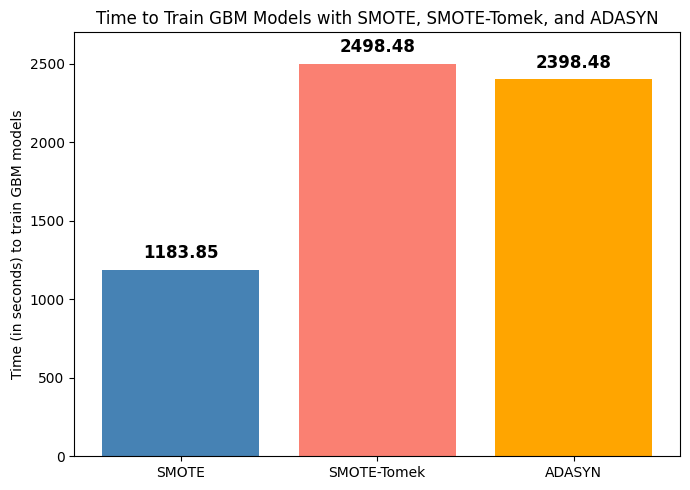

In [ ]:
import matplotlib.pyplot as plt

# Updated training times (in seconds)
training_times = {
    'SMOTE': 1183.85,
    'SMOTE-Tomek': 2498.48,
    'ADASYN': 2398.48
}

plt.figure(figsize=(7,5))
plt.bar(training_times.keys(), training_times.values(), color=['steelblue', 'salmon', 'orange'])

# Add text labels on top of each bar
for i, (k, v) in enumerate(training_times.items()):
    plt.text(i, v + 50, f'{v:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, max(training_times.values()) + 200)
plt.ylabel('Time (in seconds) to train GBM models')
plt.title('Time to Train GBM Models with SMOTE, SMOTE-Tomek, and ADASYN')
plt.tight_layout()
plt.show()


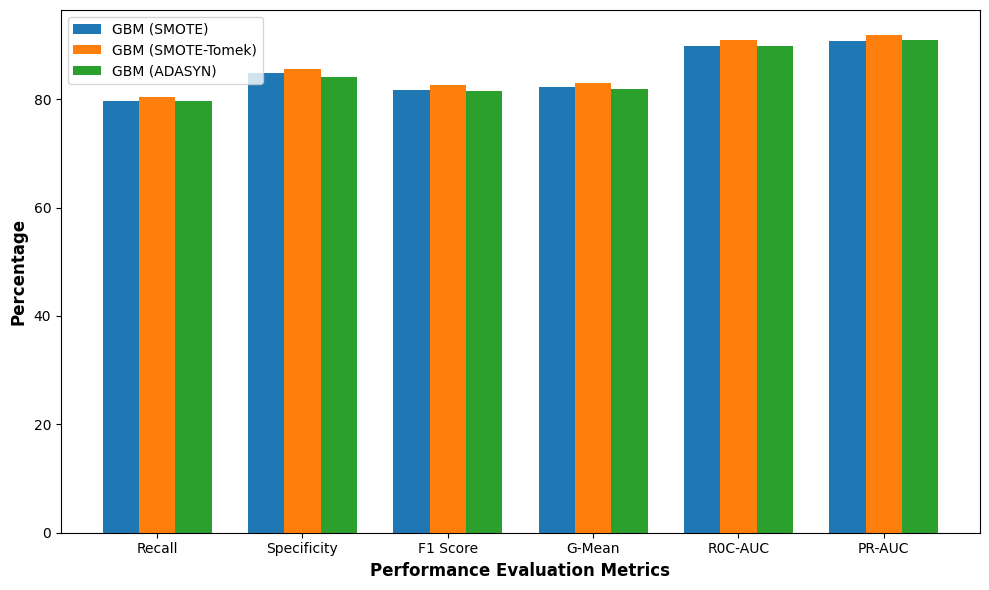

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Models': ['GBM (SMOTE)', 'GBM (SMOTE-Tomek)', 'GBM (ADASYN)'],
    'Recall': [79.61, 80.42, 79.71],
    'Specificity': [84.82, 85.62, 84.06],
    'F1 Score': [81.74, 82.56, 81.48],
    'G-Mean': [82.18, 82.98, 81.85],
    'R0C-AUC': [89.73, 90.90, 89.72],
    'PR-AUC': [90.76, 91.85, 90.82]
}

df = pd.DataFrame(data)


# Selecting the columns to plot
metrics_to_plot = ['Recall', 'Specificity', 'F1 Score','G-Mean','R0C-AUC', 'PR-AUC']
models = df['Models']
values = df[metrics_to_plot]


# Adjusting the plot to have metrics on the horizontal axis and models represented as legend

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# We need to plot each metric's value for each model as a separate bar, and group them by metric
# Since we have 4 models, we will create 4 sets of bars, one for each model

# Set the position of the bars on the x-axis
bar_positions = list(range(len(metrics_to_plot)))

# The width of a bar
bar_width = 0.25

# Setting the position of the grouped bars
model_positions = [bar_positions]
for i in range(1, len(models)):
    model_positions.append([x + bar_width for x in model_positions[i-1]])

# Plotting each set of bars for each model
for i, model in enumerate(models):
    plt.bar(model_positions[i], df.loc[df['Models'] == model, metrics_to_plot].values.flatten(),
            width=bar_width, label=model)

# Adding labels and title
plt.xlabel('Performance Evaluation Metrics', fontweight='bold', fontsize=12)
plt.ylabel('Percentage', fontweight='bold', fontsize=12)
#plt.title('Comparison of the Methods Based on the Metrics Considered')

# Adding the xticks, with a slight adjustment in position to centre them
plt.xticks([r + bar_width for r in range(len(metrics_to_plot))], metrics_to_plot)

# Adding the legend and showing the plot
plt.legend()
plt.tight_layout()
plt.show()

# Without Oversampling Technique

In [ ]:
# Load the data
df = pd.read_csv("/content/Borutta_DBSCAN.csv")

# Convert target to numeric
df['Default Payment'] = df['Default Payment'].map({'No': 0, 'Yes': 1})

# Separate features and target
X = df.drop('Default Payment', axis=1)
y = df['Default Payment']

In [ ]:
df.head()

,LIMIT_BAL,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default Payment
0,93333,3,3,3,3,3,3,29239,14327,13559,14331,14948,15549,1518,1533,1333,1333,1333,5333,No
1,53333,3,3,3,3,3,3,46993,48233,49291,28314,28959,29547,2333,2319,1233,1133,1369,1333,No
2,53333,3,3,3,3,3,3,64433,57369,57638,19394,19619,23324,2533,1815,657,1333,1333,833,No
3,143333,3,3,2,3,3,3,11285,14396,12138,12211,11793,3719,3329,3,432,1333,1333,1333,No
4,253333,3,3,3,3,3,3,73887,67363,63561,59696,56875,55512,3333,3333,3333,3333,3333,3333,No


# Naive Bayes

Best Hyperparameters: {'var_smoothing': np.float64(1e-11)}
Time to train (seconds): 3.47

Train Metrics:
Accuracy: 0.4669
Recall: 0.7884
Specificity: 0.3773
F1-Score: 0.3920
AUC: 0.6262
G-mean: 0.5454
Fbeta-Measure (beta=2): 0.5614

Test Metrics:
Accuracy: 0.4726
Recall: 0.7627
Specificity: 0.3917
F1-Score: 0.3869
AUC: 0.6048
G-mean: 0.5466
Fbeta-Measure (beta=2): 0.5493


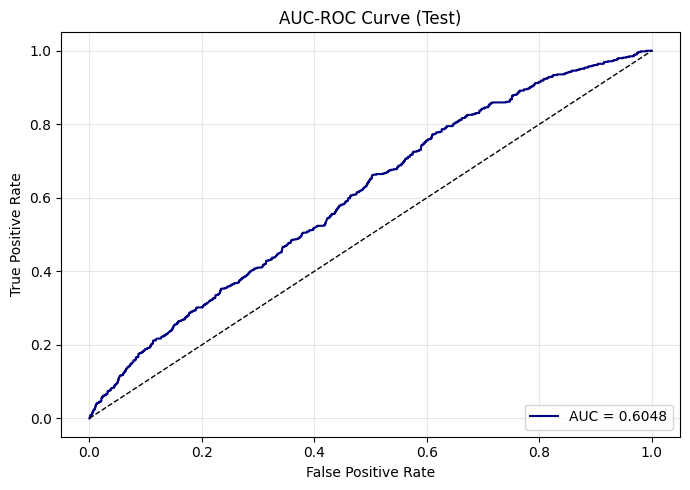

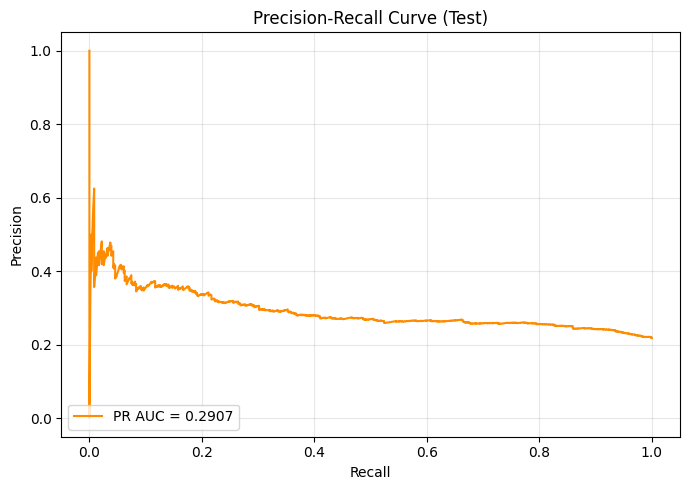

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data (no SMOTE here, just original data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Naive Bayes with GridSearchCV (tuning var_smoothing)
param_grid = {
    'var_smoothing': np.logspace(-11, -7, 5)  # Example: [1e-11, 1e-10, ..., 1e-7]
}

scorer = make_scorer(f1_score)
nb = GaussianNB()

start_time = time.time()
clf = GridSearchCV(nb, param_grid, cv=5, scoring=scorer, n_jobs=-1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# K-NN

Best Hyperparameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Time to train (seconds): 80.54

Train Metrics:
Accuracy: 0.9780
Recall: 0.9389
Specificity: 0.9889
F1-Score: 0.9490
AUC: 0.9874
G-mean: 0.9636
Fbeta-Measure (beta=2): 0.9429

Test Metrics:
Accuracy: 0.7311
Recall: 0.2373
Specificity: 0.8690
F1-Score: 0.2781
AUC: 0.5827
G-mean: 0.4541
Fbeta-Measure (beta=2): 0.2521


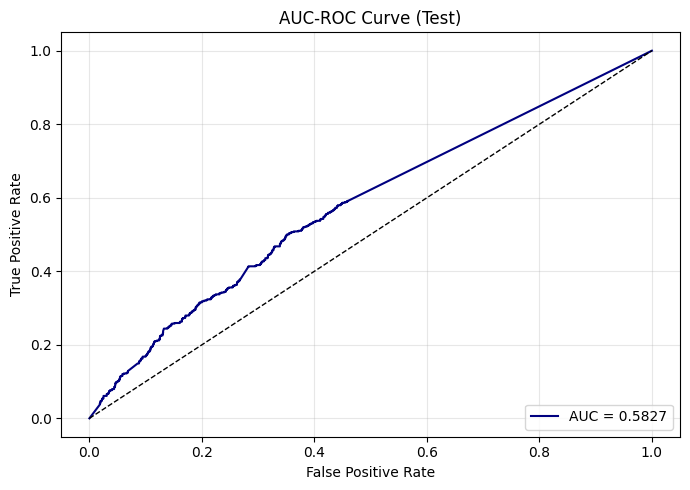

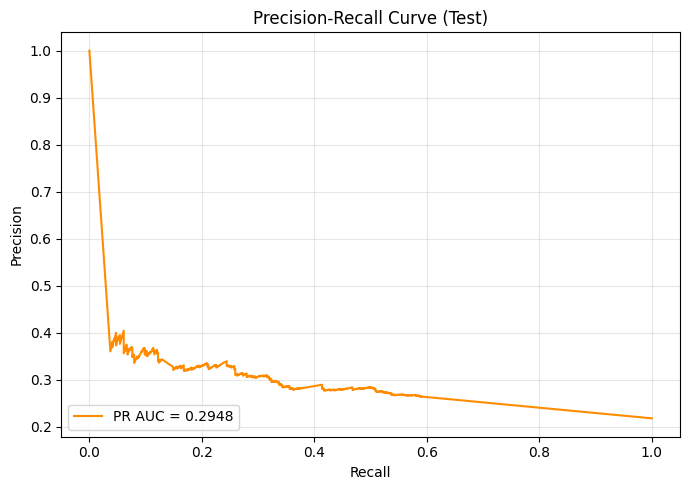

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. K-NN with GridSearchCV (tuning n_neighbors, weights, metric)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

scorer = make_scorer(f1_score)
knn = KNeighborsClassifier()

start_time = time.time()
clf = GridSearchCV(knn, param_grid, cv=5, scoring=scorer, n_jobs=-1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# XGBoost

Fitting 5 folds for each of 192 candidates, totalling 960 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:02:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Hyperparameters: {'colsample_bytree': 1.0, 'gamma': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Time to train (seconds): 294.09

Train Metrics:
Accuracy: 0.8339
Recall: 0.3422
Specificity: 0.9710
F1-Score: 0.4733
AUC: 0.8689
G-mean: 0.5765
Fbeta-Measure (beta=2): 0.3849

Test Metrics:
Accuracy: 0.8062
Recall: 0.2661
Specificity: 0.9570
F1-Score: 0.3747
AUC: 0.7514
G-mean: 0.5046
Fbeta-Measure (beta=2): 0.3010


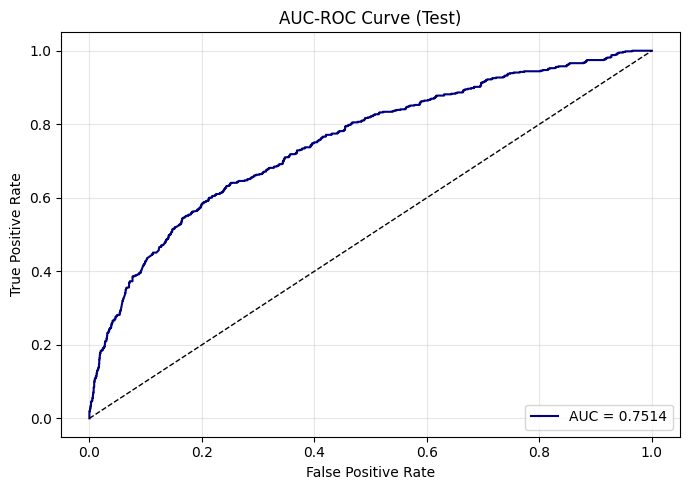

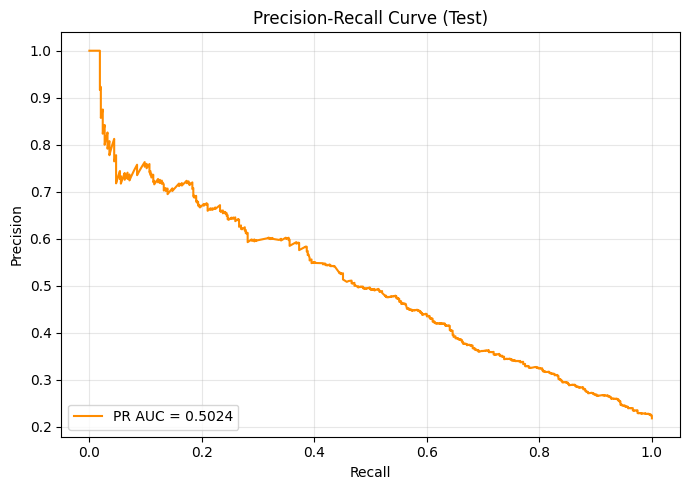

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. XGBoost with GridSearchCV (expanded params)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2,3,4,5],
    'learning_rate': [0.001, 0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 1]
}

scorer = make_scorer(f1_score)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

start_time = time.time()
clf = GridSearchCV(xgb, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# AdaBoost

Fitting 5 folds for each of 18 candidates, totalling 90 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
45 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_

Best Hyperparameters: {'algorithm': 'SAMME', 'learning_rate': 1.0, 'n_estimators': 200}
Time to train (seconds): 94.95

Train Metrics:
Accuracy: 0.8103
Recall: 0.2553
Specificity: 0.9650
F1-Score: 0.3698
AUC: 0.7566
G-mean: 0.4964
Fbeta-Measure (beta=2): 0.2914

Test Metrics:
Accuracy: 0.8047
Recall: 0.2475
Specificity: 0.9603
F1-Score: 0.3561
AUC: 0.7505
G-mean: 0.4875
Fbeta-Measure (beta=2): 0.2819


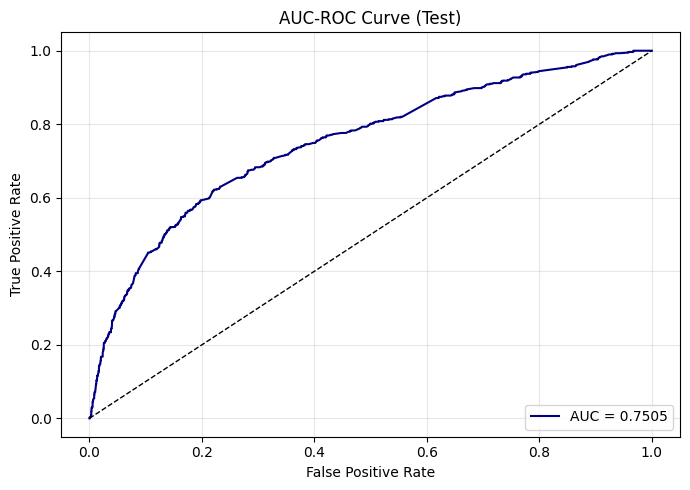

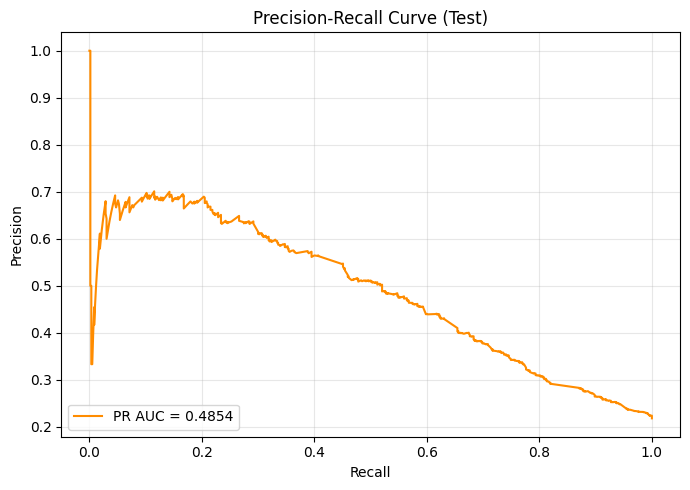

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. AdaBoost with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'algorithm': ['SAMME', 'SAMME.R']
}

scorer = make_scorer(f1_score)
ada = AdaBoostClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(ada, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# GBM

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 7, 'max_features': None, 'n_estimators': 100, 'subsample': 0.5}
Time to train (seconds): 1669.48

Train Metrics:
Accuracy: 0.8849
Recall: 0.5246
Specificity: 0.9853
F1-Score: 0.6652
AUC: 0.9497
G-mean: 0.7190
Fbeta-Measure (beta=2): 0.5731

Test Metrics:
Accuracy: 0.8014
Recall: 0.2831
Specificity: 0.9461
F1-Score: 0.3835
AUC: 0.7370
G-mean: 0.5175
Fbeta-Measure (beta=2): 0.3162


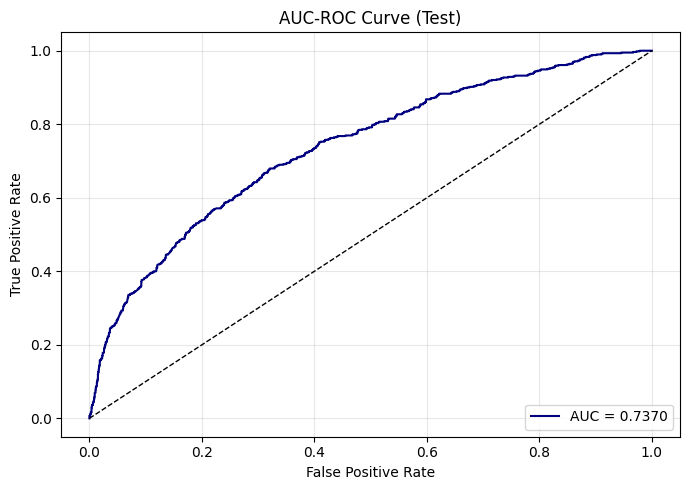

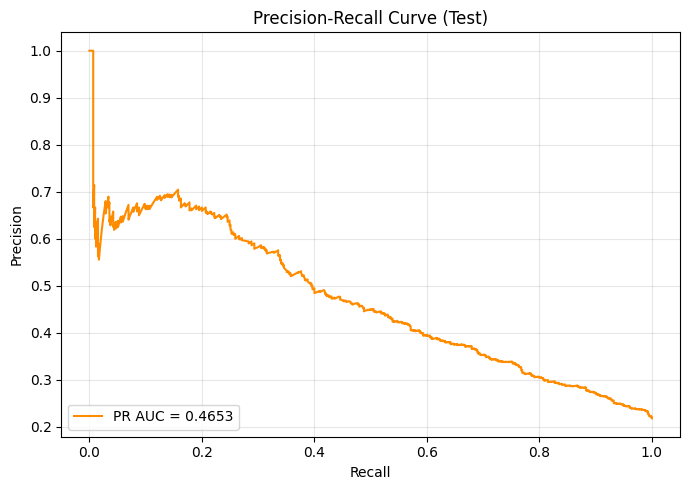

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
                            precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Gradient Boosting with GridSearchCV
param_grid = {
    'n_estimators': [50, 100,150],
    'learning_rate': [0.001,0.01, 0.1],
    'max_depth': [3, 5,7],
    'subsample': [0.5, 1.0],
    'max_features': [None, 'sqrt']
}

scorer = make_scorer(f1_score)
gbm = GradientBoostingClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(gbm, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Light GBM

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
[LightGBM] [Info] Number of positive: 2358, number of negative: 8458
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000779 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3154
[LightGBM] [Info] Number of data points in the train set: 10816, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218010 -> initscore=-1.277299
[LightGBM] [Info] Start training from score -1.277299
Best Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'num_leaves': 15, 'subsample': 0.5}
Time to train (seconds): 223.97

Train Metrics:
Accuracy: 0.8285
Recall: 0.3219
Specificity: 0.9697
F1-Score: 0.4500
AUC: 0.8500
G-mean: 0.5587
Fbeta-Measure (beta=2): 0.3633

Test Metrics:
Accuracy: 0.8077
Recall: 0.2695
Specificity: 0.

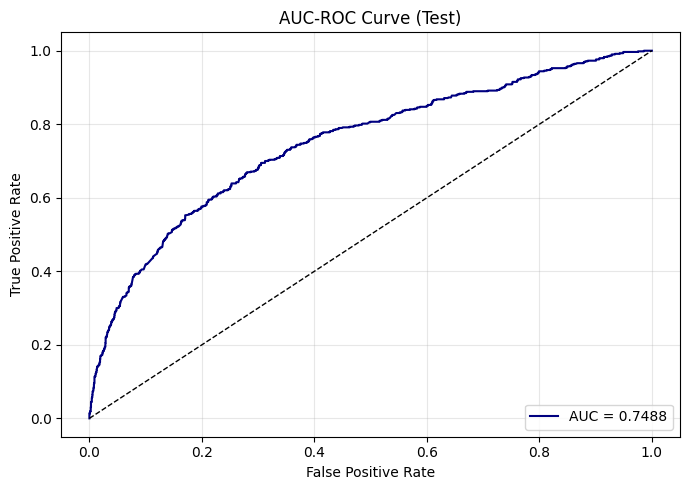

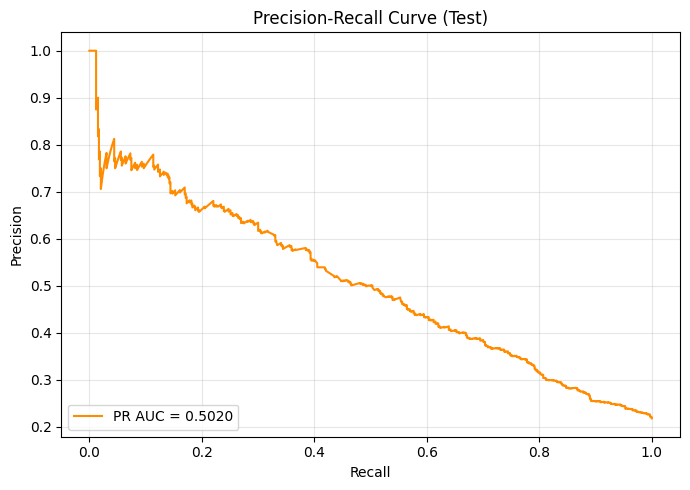

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
    precision_recall_curve, roc_curve, auc, make_scorer, fbeta_score
)
import matplotlib.pyplot as plt

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. LightGBM with GridSearchCV (expanded params)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5,7],
    'learning_rate': [0.001,0.01, 0.1],
    'num_leaves': [5,10,15,20],
    'subsample': [0.5, 1.0],
    'colsample_bytree': [0.5, 1.0]
}

scorer = make_scorer(f1_score)
lgbm = LGBMClassifier(random_state=42)

start_time = time.time()
clf = GridSearchCV(lgbm, param_grid, cv=5, scoring=scorer, n_jobs=-1, verbose=1)
clf.fit(X_train, y_train)
end_time = time.time()
elapsed_time = end_time - start_time

best_model = clf.best_estimator_

# Predict (Train)
y_pred_train = best_model.predict(X_train)
y_prob_train = best_model.predict_proba(X_train)[:, 1]

# Predict (Test)
y_pred_test = best_model.predict(X_test)
y_prob_test = best_model.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp)
    f1 = f1_score(y_true, y_pred)
    auc_s = roc_auc_score(y_true, y_prob)
    gmean = np.sqrt(rec * spec)
    fbeta = fbeta_score(y_true, y_pred, beta=2)
    return acc, rec, spec, f1, auc_s, gmean, fbeta

# Train metrics
train_metrics = get_metrics(y_train, y_pred_train, y_prob_train)
# Test metrics
test_metrics = get_metrics(y_test, y_pred_test, y_prob_test)

# Print results
print(f"Best Hyperparameters: {clf.best_params_}")
print(f"Time to train (seconds): {elapsed_time:.2f}\n")

metric_names = ["Accuracy", "Recall", "Specificity", "F1-Score", "AUC", "G-mean", "Fbeta-Measure (beta=2)"]
print("Train Metrics:")
for n, v in zip(metric_names, train_metrics):
    print(f"{n}: {v:.4f}")

print("\nTest Metrics:")
for n, v in zip(metric_names, test_metrics):
    print(f"{n}: {v:.4f}")

# 7. AUC-ROC Plot (Test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {test_metrics[4]:.4f}', color='navy')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve (Test)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Precision-Recall Curve Plot (Test)
precision, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
pr_auc = auc(recall_curve, precision)
plt.figure(figsize=(7,5))
plt.plot(recall_curve, precision, label=f'PR AUC = {pr_auc:.4f}', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

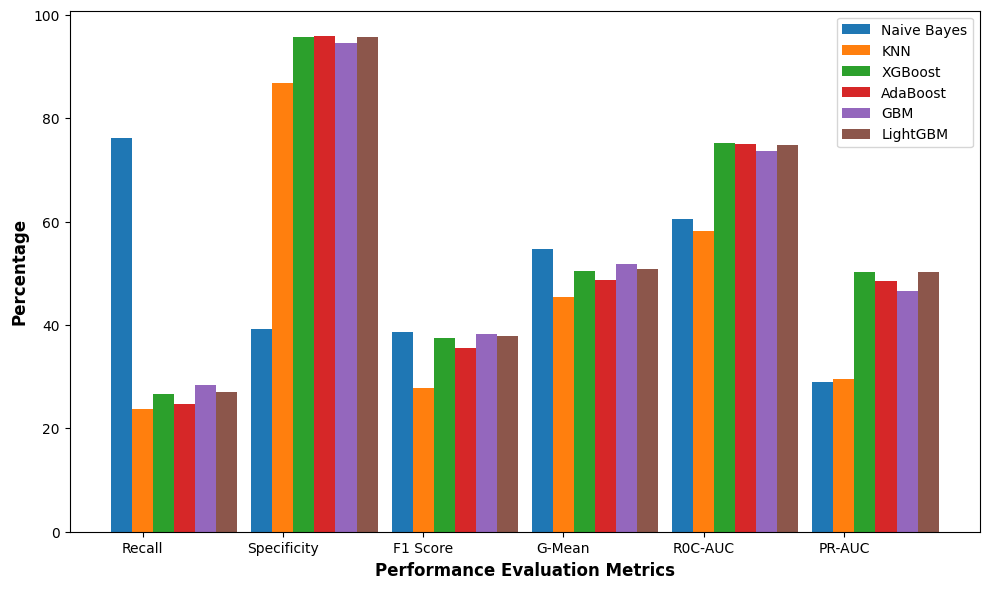

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Models': ['Naive Bayes', 'KNN', 'XGBoost','AdaBoost','GBM','LightGBM'],
    'Recall': [76.27, 23.73, 26.61,24.75,28.31,26.95],
    'Specificity': [39.17,86.90, 95.70,96.03,94.61,95.79],
    'F1 Score': [38.69, 27.81, 37.47,35.61,38.35,37.95],
    'G-Mean': [54.66, 45.41, 50.46,48.75,51.75,50.81],
    'R0C-AUC': [60.48, 58.27, 75.14,75.05,73.70,74.88],
    'PR-AUC': [29.07, 29.48, 50.24, 48.54,46.53,50.20]
}

df = pd.DataFrame(data)


# Selecting the columns to plot
metrics_to_plot = ['Recall', 'Specificity', 'F1 Score','G-Mean','R0C-AUC', 'PR-AUC']
models = df['Models']
values = df[metrics_to_plot]


# Adjusting the plot to have metrics on the horizontal axis and models represented as legend

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))


# Set the position of the bars on the x-axis
bar_positions = list(range(len(metrics_to_plot)))

# The width of a bar
bar_width = 0.15

# Setting the position of the grouped bars
model_positions = [bar_positions]
for i in range(1, len(models)):
    model_positions.append([x + bar_width for x in model_positions[i-1]])

# Plotting each set of bars for each model
for i, model in enumerate(models):
    plt.bar(model_positions[i], df.loc[df['Models'] == model, metrics_to_plot].values.flatten(),
            width=bar_width, label=model)

# Adding labels and title
plt.xlabel('Performance Evaluation Metrics', fontweight='bold', fontsize=12)
plt.ylabel('Percentage', fontweight='bold', fontsize=12)
#plt.title('Comparison of the Methods Based on the Metrics Considered')

# Adding the xticks, with a slight adjustment in position to centre them
plt.xticks([r + bar_width for r in range(len(metrics_to_plot))], metrics_to_plot)

# Adding the legend and showing the plot
plt.legend()
plt.tight_layout()
plt.show()